### Pathway for .dat files

In [1]:
pathway = 'C:\\Users\\kajka\\OneDrive\\Documents\\root\\'

### Plotting script (dat file input) 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

def clustr_pixel_dual(
    dat_file_path,
    event=None,
    energy_threshold=0,
    time_threshold=None,
    cluster_size_min=None,
    cluster_size_max=None
):
    
    # Load file
    df = pd.read_csv(dat_file_path, sep=r"\s+", comment="#",
                     names=["X", "Y", "ToT_keV", "ToA_ns", "Counter"])

    # Cluster size filtering
    if cluster_size_min is not None or cluster_size_max is not None:
        cluster_sizes = df.groupby("Counter").size()
        valid_events = cluster_sizes.index[
            (cluster_size_min is None or cluster_sizes >= cluster_size_min) &
            (cluster_size_max is None or cluster_sizes <= cluster_size_max)
        ]
        df = df[df["Counter"].isin(valid_events)]

    # Event filtering
    if event is not None:
        if np.isscalar(event):
            event = [event]
        df = df[df["Counter"].isin(event)]

    if df.empty:
        raise ValueError("No hits match the event/cluster selection.")

    # Energy grid
    df_energy = df[df["ToT_keV"] >= energy_threshold]
    energy_grid = np.zeros((256, 256))
    for _, row in df_energy.iterrows():
        xi, yi = int(row["X"]), int(row["Y"])
        if 0 <= xi < 256 and 0 <= yi < 256:
            energy_grid[yi, xi] += row["ToT_keV"]

    # Time grid (per-event zeroed)
    time_grid = np.zeros((256, 256))
    for counter, group in df.groupby("Counter"):
        if group.empty:
            continue
        group = group.copy()
        group["ToA_rel"] = group["ToA_ns"] - group["ToA_ns"].min()
        if time_threshold is not None:
            group = group[group["ToA_rel"] <= time_threshold]
        
        for _, row in group.iterrows():
            xi, yi = int(row["X"]), int(row["Y"])
            if 0 <= xi < 256 and 0 <= yi < 256:
                time_grid[yi, xi] += row["ToA_rel"]

    if np.all(energy_grid == 0) and np.all(time_grid == 0):
        raise ValueError("No data after applying thresholds.")

    # Colormap
    cmap = plt.get_cmap("jet")
    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]  # white for zero
    new_cmap = ListedColormap(new_colors)
    x_edges = y_edges = np.arange(0, 257)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Energy plot
    energy_safe = np.where(energy_grid > 0, energy_grid, np.nan)
    if np.all(np.isnan(energy_safe)):
        vmin, vmax = 1, 1
    else:
        vmin, vmax = np.nanmin(energy_safe), np.nanmax(energy_safe)
    pcm1 = ax1.pcolormesh(
        x_edges, y_edges, energy_safe,
        cmap=new_cmap, norm=LogNorm(vmin=vmin, vmax=vmax),
        shading="auto"
    )
    ax1.set_title("Energy (ToT_keV)")
    ax1.set_xlim(0, 256); ax1.set_ylim(0, 256); ax1.set_aspect("equal")
    ax1.set_xlabel("X pixel"); ax1.set_ylabel("Y pixel")
    cbar1 = plt.colorbar(pcm1, ax=ax1, pad=0.01)
    cbar1.set_label("Energy [keV]")

    # Time plot
    time_safe = np.where(time_grid > 0, time_grid, np.nan)
    if np.all(np.isnan(time_safe)):
        vmin, vmax = 1, 1
    else:
        vmin, vmax = np.nanmin(time_safe), np.nanmax(time_safe)
    pcm2 = ax2.pcolormesh(
        x_edges, y_edges, time_safe,
        cmap=new_cmap, norm=None,
        shading="auto"
    )
    ax2.set_title("Time (ToA_ns, per-event zeroed)")
    ax2.set_xlim(0, 256); ax2.set_ylim(0, 256); ax2.set_aspect("equal")
    ax2.set_xlabel("X pixel"); ax2.set_ylabel("Y pixel")
    cbar2 = plt.colorbar(pcm2, ax=ax2, pad=0.01)
    cbar2.set_label("Time [ns]")

    # Information box
    if event is not None:
        if len(event) == 1:
            title_event = f"Event {event[0]}"
        else:
            title_event = f"Events {min(event)}–{max(event)}"
    else:
        title_event = "All Events"

    info_text = (
        f"{title_event}\n"
        f"Energy threshold: {energy_threshold} keV\n"
        f"Time threshold: {time_threshold} ns\n"
        f"Cluster size: "
        f"{cluster_size_min if cluster_size_min is not None else 'any'}–"
        f"{cluster_size_max if cluster_size_max is not None else 'any'} pixels"
    )
    fig.text(0.02, 0.98, info_text, fontsize=10, va="top",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7))

    plt.tight_layout()
    plt.show()


### Plotting script (dataframe input)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

def clustr_pixel_df_input(
    df,
    event=None,
    energy_threshold=0,
    time_threshold=None,
    cluster_size_min=None,
    cluster_size_max=None
):
    
    # Cluster size filtering
    if cluster_size_min is not None or cluster_size_max is not None:
        cluster_sizes = df.groupby("Counter").size()
        valid_events = cluster_sizes.index[
            (cluster_size_min is None or cluster_sizes >= cluster_size_min) &
            (cluster_size_max is None or cluster_sizes <= cluster_size_max)
        ]
        df = df[df["Counter"].isin(valid_events)]

    # Event filtering
    if event is not None:
        if np.isscalar(event):
            event = [event]
        elif isinstance(event, range):
            event = list(event)
        df = df[df["EventID"].isin(event)]

    if df.empty:
        raise ValueError("No hits match the event/cluster selection.")

    # Energy grid
    df_energy = df[df["ToT_keV"] >= energy_threshold]
    energy_grid = np.zeros((256, 256))
    for _, row in df_energy.iterrows():
        xi, yi = int(row["X"]), int(row["Y"])
        if 0 <= xi < 256 and 0 <= yi < 256:
            energy_grid[yi, xi] += row["ToT_keV"]

    # Time grid (per-event zeroed)
    time_grid = np.zeros((256, 256))
    for counter, group in df.groupby("EventID", observed=False):
        if group.empty:
            continue
        group = group.copy()
        group["ToA_rel"] = group["ToA_ns"] - group["ToA_ns"].min()
        if time_threshold is not None:
            group = group[group["ToA_rel"] <= time_threshold]
        
        for _, row in group.iterrows():
            xi, yi = int(row["X"]), int(row["Y"])
            if 0 <= xi < 256 and 0 <= yi < 256:
                time_grid[yi, xi] += row["ToA_rel"]

    if np.all(energy_grid == 0) and np.all(time_grid == 0):
        raise ValueError("No data after applying thresholds.")

    # Colormap
    cmap = plt.get_cmap("jet")
    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]  # white for zero
    new_cmap = ListedColormap(new_colors)
    x_edges = y_edges = np.arange(0, 257)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Energy plot
    energy_safe = np.where(energy_grid > 0, energy_grid, np.nan)
    if np.all(np.isnan(energy_safe)):
        vmin, vmax = 1, 1
    else:
        vmin, vmax = np.nanmin(energy_safe), np.nanmax(energy_safe)
    pcm1 = ax1.pcolormesh(
        x_edges, y_edges, energy_safe,
        cmap=new_cmap, norm=LogNorm(vmin=vmin, vmax=vmax),
        shading="auto"
    )
    ax1.set_title("Energy (ToT_keV)")
    ax1.set_xlim(0, 256); ax1.set_ylim(0, 256); ax1.set_aspect("equal")
    ax1.set_xlabel("X pixel"); ax1.set_ylabel("Y pixel")
    cbar1 = plt.colorbar(pcm1, ax=ax1, pad=0.01)
    cbar1.set_label("Energy [keV]")

    # Time plot
    time_safe = np.where(time_grid > 0, time_grid, np.nan)
    if np.all(np.isnan(time_safe)):
        vmin, vmax = 1, 1
    else:
        vmin, vmax = np.nanmin(time_safe), np.nanmax(time_safe)
    pcm2 = ax2.pcolormesh(
        x_edges, y_edges, time_safe,
        cmap=new_cmap, norm=None,
        shading="auto"
    )
    ax2.set_title("Time (ToA_ns, per-event zeroed)")
    ax2.set_xlim(0, 256); ax2.set_ylim(0, 256); ax2.set_aspect("equal")
    ax2.set_xlabel("X pixel"); ax2.set_ylabel("Y pixel")
    cbar2 = plt.colorbar(pcm2, ax=ax2, pad=0.01)
    cbar2.set_label("Time [ns]")

    # Information box
    if event is not None:
        if len(event) == 1:
            title_event = f"Event {event[0]}"
        else:
            title_event = f"Events {min(event)}–{max(event)}"
    else:
        title_event = "All Events"

    info_text = (
        f"{title_event}\n"
        f"Energy threshold: {energy_threshold} keV\n"
        f"Time threshold: {time_threshold} ns\n"
        f"Cluster size: "
        f"{cluster_size_min if cluster_size_min is not None else 'any'}–"
        f"{cluster_size_max if cluster_size_max is not None else 'any'} pixels"
    )
    fig.text(0.02, 0.98, info_text, fontsize=10, va="top",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7))

    plt.tight_layout()
    plt.show()


### Converting the dat file into a dataframe (mixing events, filtering out edge events)

In [4]:
import pandas as pd
import glob

# List of my files
files = [
    pathway + "proton_15deg.dat",
    pathway + "proton_30deg.dat",
    pathway + "proton_50deg.dat",
    pathway + "proton_75deg.dat"
]

dfs = []
event_offset = 0  # Keeps track of where we left off

for f in files:
    # Loading each file
    df = pd.read_csv(
        f,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["X", "Y", "ToT_keV", "ToA_ns", "Counter"]
    )
    
    # Shift Counter so it continues from previous max
    df["Counter"] = df["Counter"] + event_offset
    
    # Update offset for next file
    event_offset = df["Counter"].max()
    
    dfs.append(df)

# Combine everything
df_all = pd.concat(dfs, ignore_index=True)

# Shuffle events (keeping hits per event together)
unique_events = df_all["Counter"].unique()
shuffled_events = pd.Series(unique_events).sample(frac=1, random_state=42).values
df_all = df_all[df_all["Counter"].isin(shuffled_events)].copy()
df_all["Counter"] = pd.Categorical(df_all["Counter"], categories=shuffled_events, ordered=True)
df_all = df_all.sort_values("Counter").reset_index(drop=True)

# Filtering events which have pixels touching a wall
touches_wall = (df_all["X"] == 0) | (df_all["X"] == 255) | (df_all["Y"] == 0) | (df_all["Y"] == 255)
wall_events = df_all.loc[touches_wall, "Counter"].unique()
proton_filtered = df_all[~df_all["Counter"].isin(wall_events)].copy()

# Summary
print(f"Original events: {df_all['Counter'].nunique()}")
print(f"Remaining events (no wall contact): {proton_filtered['Counter'].nunique()}")


Original events: 622520
Remaining events (no wall contact): 597655


In [5]:
# Make a new column with reindexed event numbers

proton_filtered = proton_filtered.copy()
unique_events = proton_filtered["Counter"].unique()
event_map = {old: new for new, old in enumerate(unique_events)}
proton_filtered["EventID"] = proton_filtered["Counter"].map(event_map)

### Energy vs cluster size plots

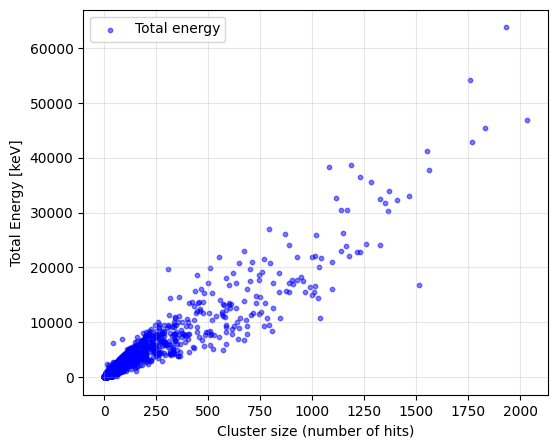

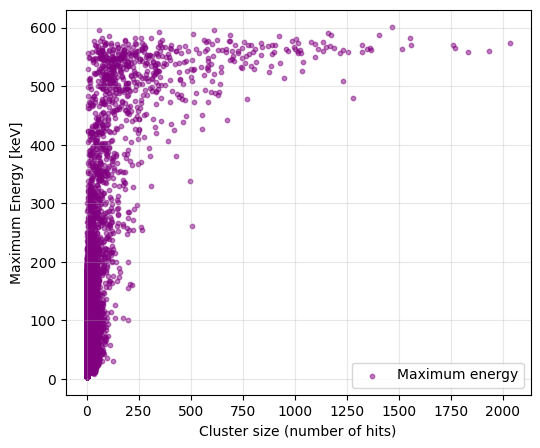

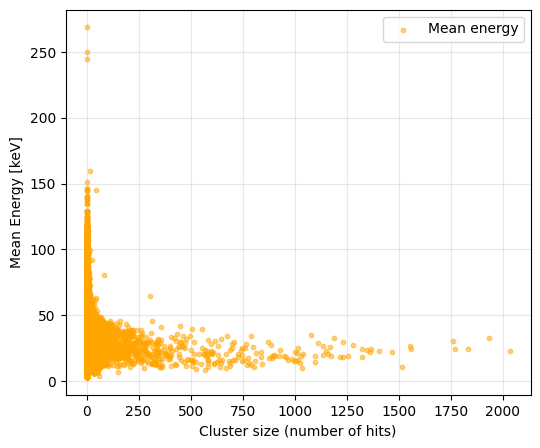

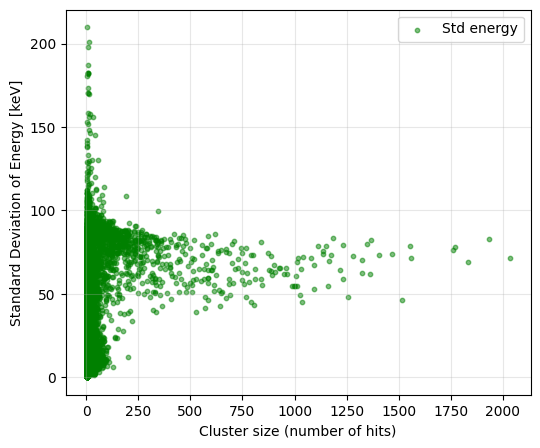

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by event
grouped_proton = proton_filtered.groupby("Counter", observed=False)
grouped = proton_filtered.groupby("Counter", observed=False)


# Compute energy and cluster size
event_summary = grouped.agg(
    total_energy=("ToT_keV", "sum"),
    cluster_size=("ToT_keV", "count"),
    maximum_energy=("ToT_keV", "max"),
    mean_energy=("ToT_keV", "mean"),
    std_energy=("ToT_keV", "std")
).reset_index()

# Total energy
plt.figure(figsize=(6,5))
plt.scatter(event_summary["cluster_size"], event_summary["total_energy"], alpha=0.5, s=10, c="blue", label='Total energy')
plt.xlabel("Cluster size (number of hits)")
plt.ylabel("Total Energy [keV]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Maximum energy
plt.figure(figsize=(6,5))
plt.scatter(event_summary["cluster_size"], event_summary["maximum_energy"], alpha=0.5, s=10, c="purple", label='Maximum energy')
plt.xlabel("Cluster size (number of hits)")
plt.ylabel("Maximum Energy [keV]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Mean energy
plt.figure(figsize=(6,5))
plt.scatter(event_summary["cluster_size"], event_summary["mean_energy"], alpha=0.5, s=10, c="orange", label='Mean energy')
plt.xlabel("Cluster size (number of hits)")
plt.ylabel("Mean Energy [keV]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Standard deviation of energy
plt.figure(figsize=(6,5))
plt.scatter(event_summary["cluster_size"], event_summary["std_energy"], alpha=0.5, s=10, c="green", label='Std energy')
plt.xlabel("Cluster size (number of hits)")
plt.ylabel("Standard Deviation of Energy [keV]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Feature extraction

In [7]:
grouped_proton = proton_filtered.groupby("Counter")
rows = []

for event_id, hits in grouped_proton:
    total_energy = hits["ToT_keV"].sum()
    max_energy = hits["ToT_keV"].max()
    mean_energy = hits["ToT_keV"].mean()
    std_energy = hits["ToT_keV"].std()
    num_hits = len(hits)
    x_spread = hits["X"].std()
    y_spread = hits["Y"].std()
    width = hits["X"].max() - hits["X"].min()
    height = hits["Y"].max() - hits["Y"].min()
    aspect = width / height if height > 0 else 0

    # Outer and inner pixels
    coords = set(zip(hits["X"], hits["Y"]))
    outer_pixels, inner_pixels = 0, 0
    for (x, y) in coords:
        neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
        neighbor_count = sum((nx,ny) in coords for (nx,ny) in neighbors)
        if neighbor_count < 4:
            outer_pixels += 1
        else:
            inner_pixels += 1

    # Volcano pixels
    hits = hits.copy()
    hits["ToA_rel"] = hits["ToA_ns"] - hits["ToA_ns"].min()
    if hits["ToT_keV"].max() > 300:
        volcano_pixels = hits[(hits["ToT_keV"] < 10) & (hits["ToA_rel"] < 20)].shape[0]
        volcano_fraction = volcano_pixels / num_hits
    else:
        volcano_fraction = 0

    rows.append({
        "Counter": event_id,
        "total_energy": total_energy,
        "max_energy": max_energy,
        "mean_energy": mean_energy,
        "std_energy": std_energy,
        "num_hits": num_hits,
        "x_spread": x_spread,
        "y_spread": y_spread,
        "width": width,
        "height": height,
        "aspect": aspect,
        "outer_pixels": outer_pixels,
        "inner_pixels": inner_pixels,
        "volcano_fraction": volcano_fraction
    })

df_features = pd.DataFrame(rows)


C:\Users\kajka\AppData\Local\Temp\ipykernel_12180\2660996726.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_proton = proton_filtered.groupby("Counter")


In [10]:
from sklearn.preprocessing import StandardScaler

feature_names = [col for col in df_features.columns if col not in ["Counter", "cluster"]]
X_p = df_features[feature_names].values
X_p = np.nan_to_num(X_p, nan=0.0, posinf=0.0, neginf=0.0)

# Scale features
X_p_scaled = StandardScaler().fit_transform(X_p)

## K-means Clustering, PCA Visualisation

Number of clusters for K-Means:  5


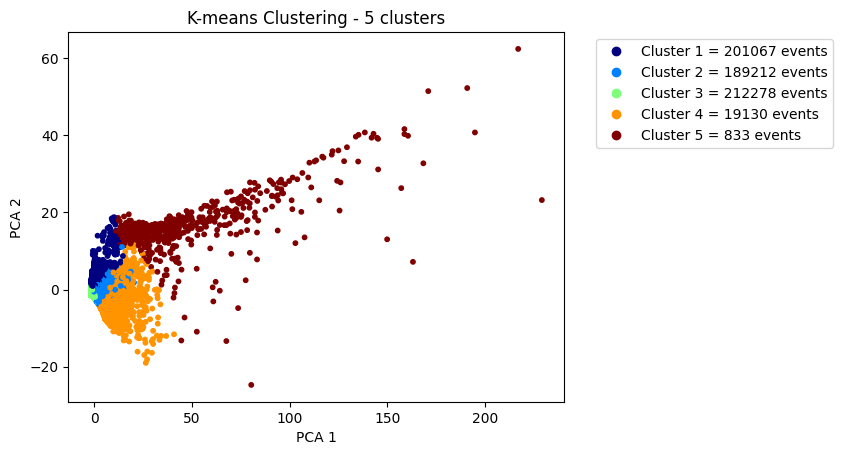


Top decisive features per DBSCAN cluster (sampled data):

Cluster 1:
  std_energy      (cluster mean = 0.990, diff = 0.990)
  mean_energy     (cluster mean = 0.882, diff = 0.882)
  max_energy      (cluster mean = 0.781, diff = 0.781)
  Plotting 500 events from cluster 1...


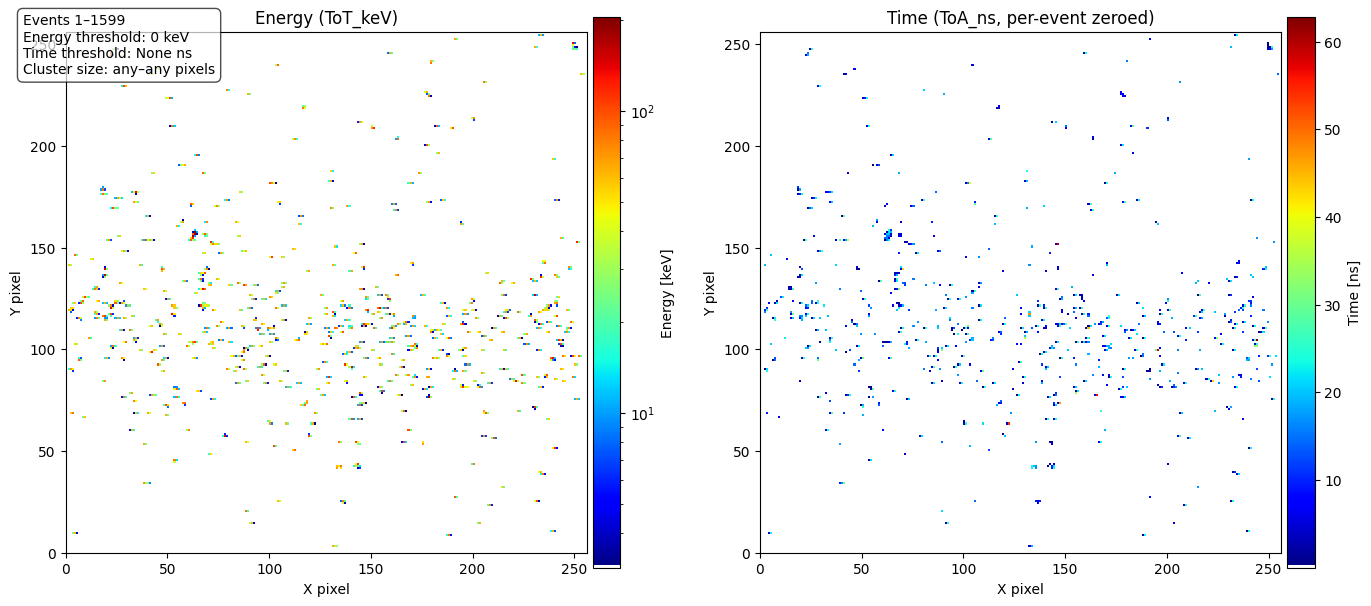


Cluster 2:
  y_spread        (cluster mean = 0.783, diff = 0.783)
  mean_energy     (cluster mean = -0.547, diff = 0.547)
  height          (cluster mean = 0.494, diff = 0.494)
  Plotting 500 events from cluster 2...


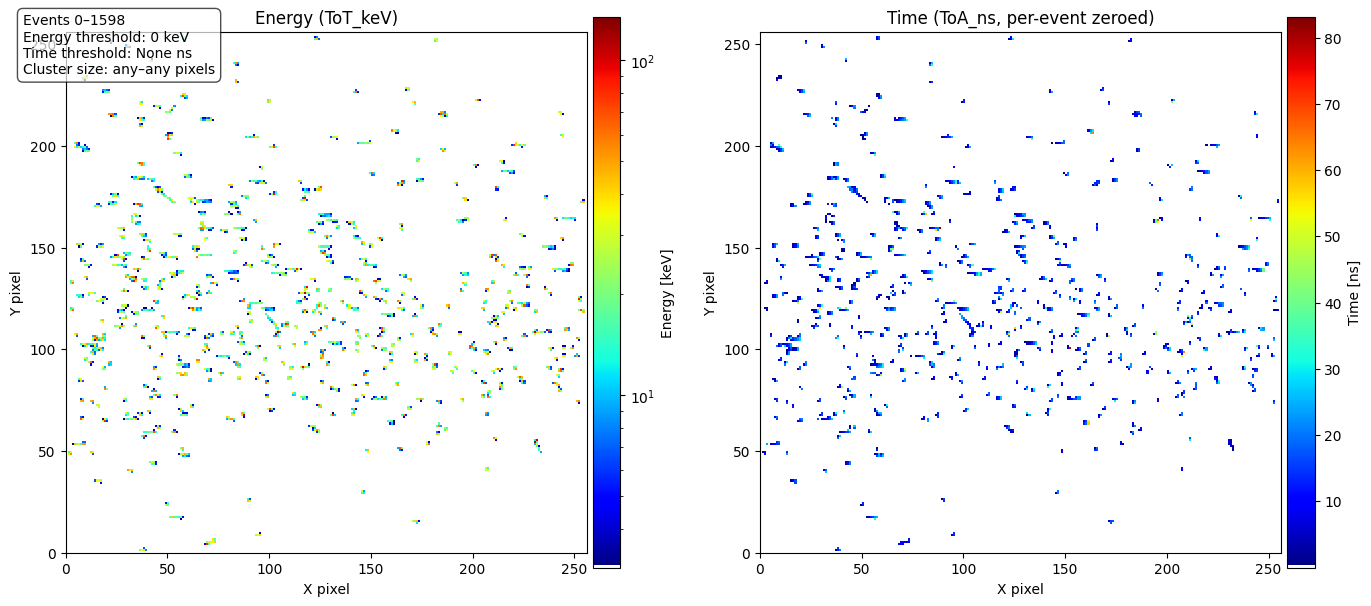


Cluster 3:
  std_energy      (cluster mean = -0.728, diff = 0.728)
  max_energy      (cluster mean = -0.562, diff = 0.562)
  y_spread        (cluster mean = -0.540, diff = 0.540)
  Plotting 500 events from cluster 3...


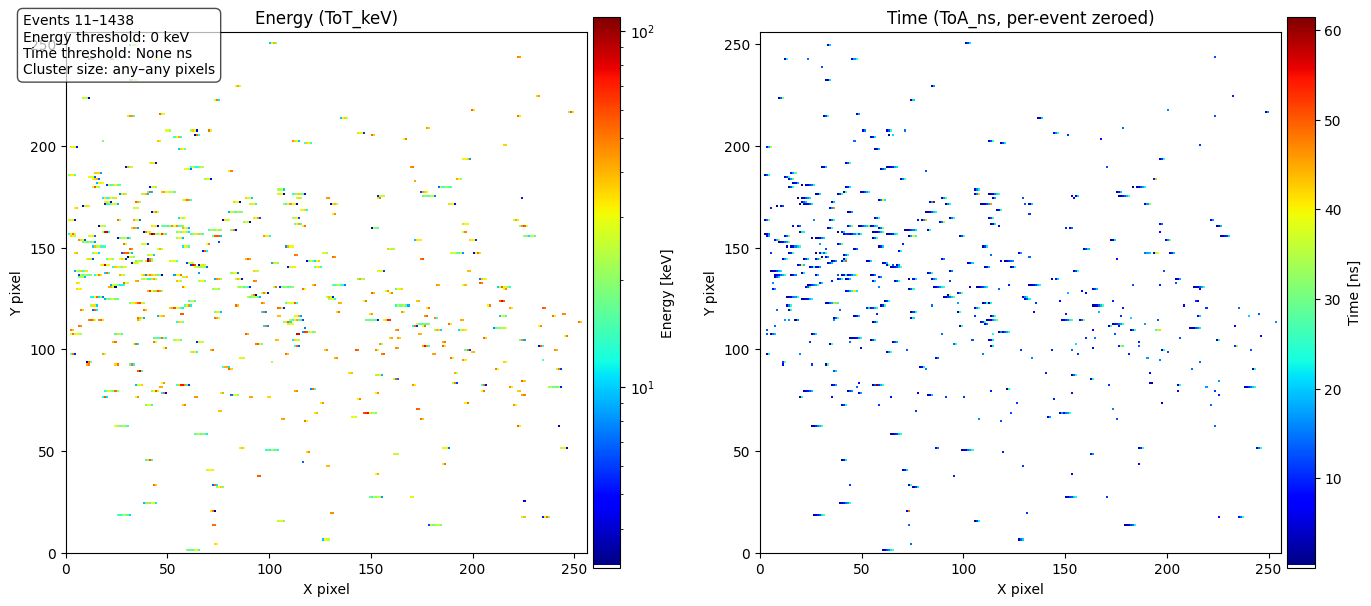


Cluster 4:
  width           (cluster mean = 4.735, diff = 4.735)
  x_spread        (cluster mean = 4.705, diff = 4.705)
  outer_pixels    (cluster mean = 3.777, diff = 3.777)
  Plotting 500 events from cluster 4...


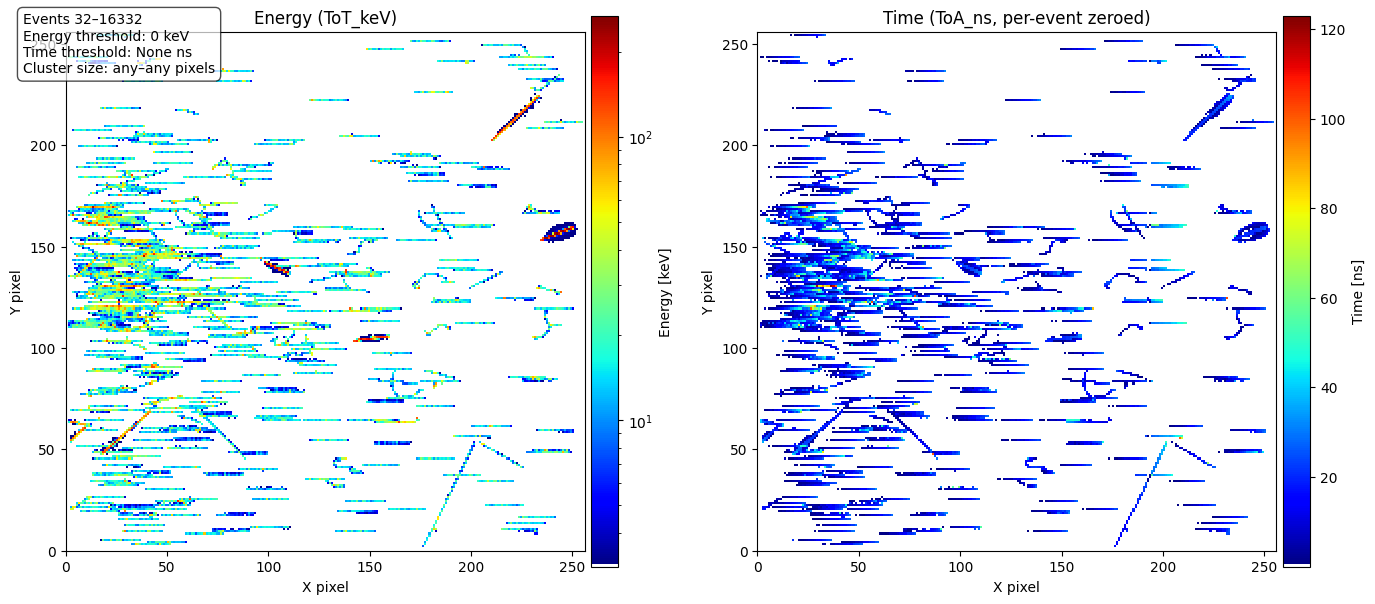


Cluster 5:
  volcano_fraction (cluster mean = 24.481, diff = 24.481)
  total_energy    (cluster mean = 17.150, diff = 17.150)
  num_hits        (cluster mean = 17.017, diff = 17.017)
  Plotting 500 events from cluster 5...


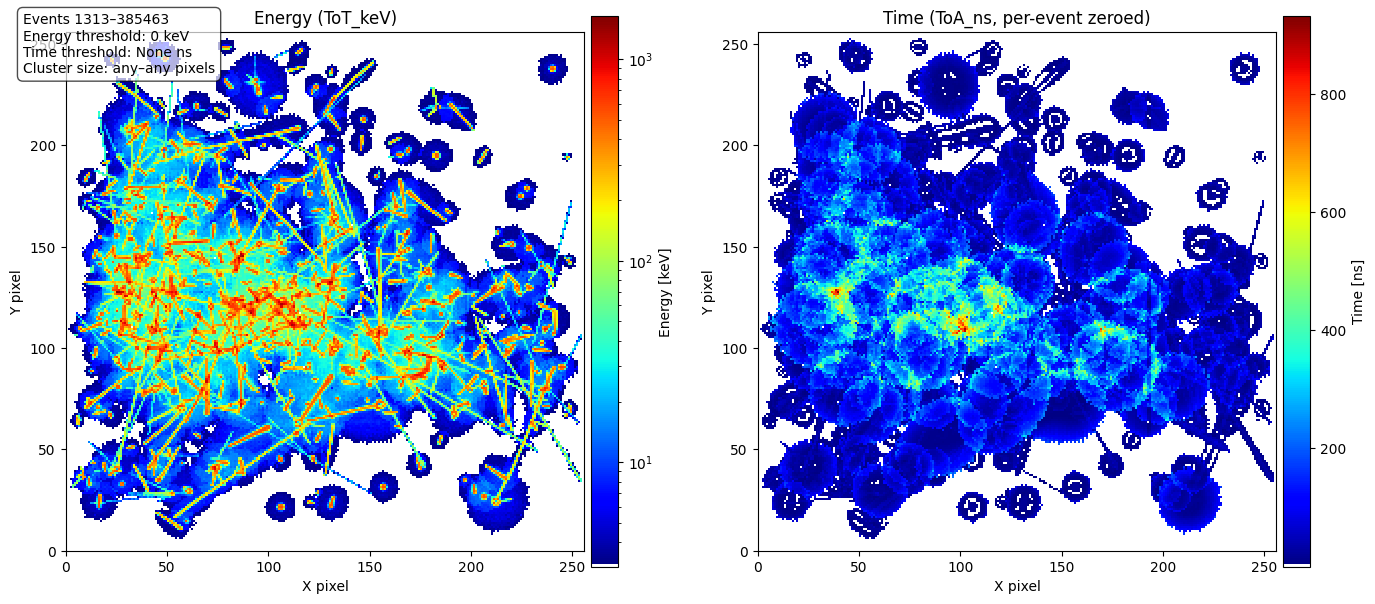

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Number of clusters for k-means
try:
    n_clusters = int(input("Number of clusters for K-Means: "))
except ValueError:
    print("Invalid input, defaulting to 3 clusters.")
    n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_p_scaled)
df_features["cluster"] = labels  # add cluster labels

# PCA for visualization
X_p_pca = PCA(n_components=2).fit_transform(X_p_scaled)

# Plotting
scatter = plt.scatter(X_p_pca[:,0], X_p_pca[:,1], c=labels, cmap="jet", s=10)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-means Clustering - " f"{n_clusters} clusters")

# Legend describing the number of events per cluster
handles, _ = scatter.legend_elements()
unique_labels, counts = np.unique(labels, return_counts=True)
legend_labels = [f"Cluster {lab+1} = {cnt} events" for lab, cnt in zip(unique_labels, counts)]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# More information about each cluster
centroids = kmeans.cluster_centers_
global_mean = np.mean(X_p_scaled, axis=0)


print("\nTop decisive features per DBSCAN cluster (sampled data):")

# Ensure proton_sampled has EventID
unique_events = df_features["Counter"].unique()
event_map = {old: new for new, old in enumerate(unique_events)}
proton_filtered["EventID"] = proton_filtered["Counter"].map(event_map)

cluster_labels = np.unique(labels)
for cl in cluster_labels:
    # Select points in this cluster
    cluster_mask = labels == cl
    cluster_points = X_p_scaled[cluster_mask]

    # Compute cluster centroid (mean feature vector)
    cluster_mean = cluster_points.mean(axis=0)

    # Compute absolute difference from global mean
    diffs = np.abs(cluster_mean - global_mean)

    # Top 3 features per cluster
    top_idx = np.argsort(diffs)[::-1][:3]

    print(f"\nCluster {cl+1}:")  # +1 to start cluster numbers at 1
    for i in top_idx:
        print(f"  {feature_names[i]:15s} (cluster mean = {cluster_mean[i]:.3f}, diff = {diffs[i]:.3f})")

    # Get the Counter IDs in this cluster
    cluster_events = df_features[cluster_mask]["Counter"].values

    # Map them to EventID in proton_sampled
    cluster_event_ids = [event_map[e] for e in cluster_events if e in event_map]

    if len(cluster_event_ids) > 0:
        # Only take the first 500 events
        sample_events = cluster_event_ids[:500]
        print(f"  Plotting {len(sample_events)} events from cluster {cl+1}...")
        clustr_pixel_df_input(proton_filtered, event=sample_events)
    else:
        print(f"  No events in proton_filtered for cluster {cl+1}")



## DBSCAN Clustering, PCA Visualisation

Enter number of events to sample for DBSCAN (max 622520):  30000


Using 30000 randomly sampled events for DBSCAN


DBSCAN eps (neighborhood radius):  2
DBSCAN min_samples (minimum cluster size):  20


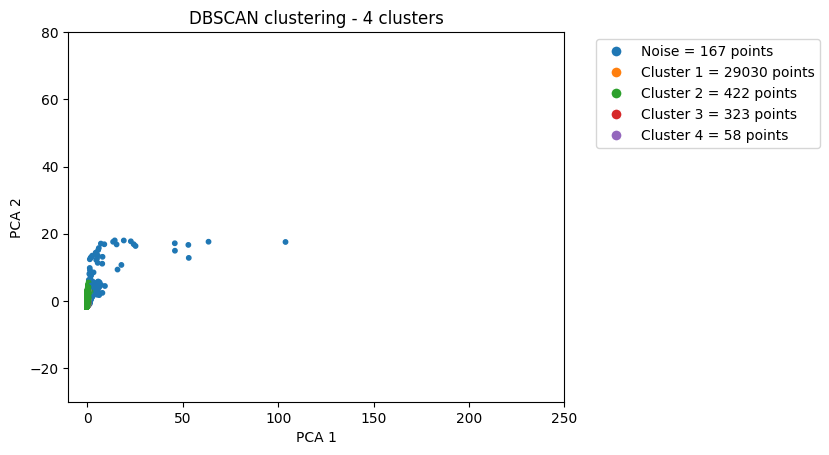


Top decisive features per DBSCAN cluster (sampled data):

Cluster 1:
  width           (cluster mean = -0.155, diff = 0.155)
  x_spread        (cluster mean = -0.151, diff = 0.151)
  outer_pixels    (cluster mean = -0.136, diff = 0.136)
  Plotting 500 events from cluster 1...


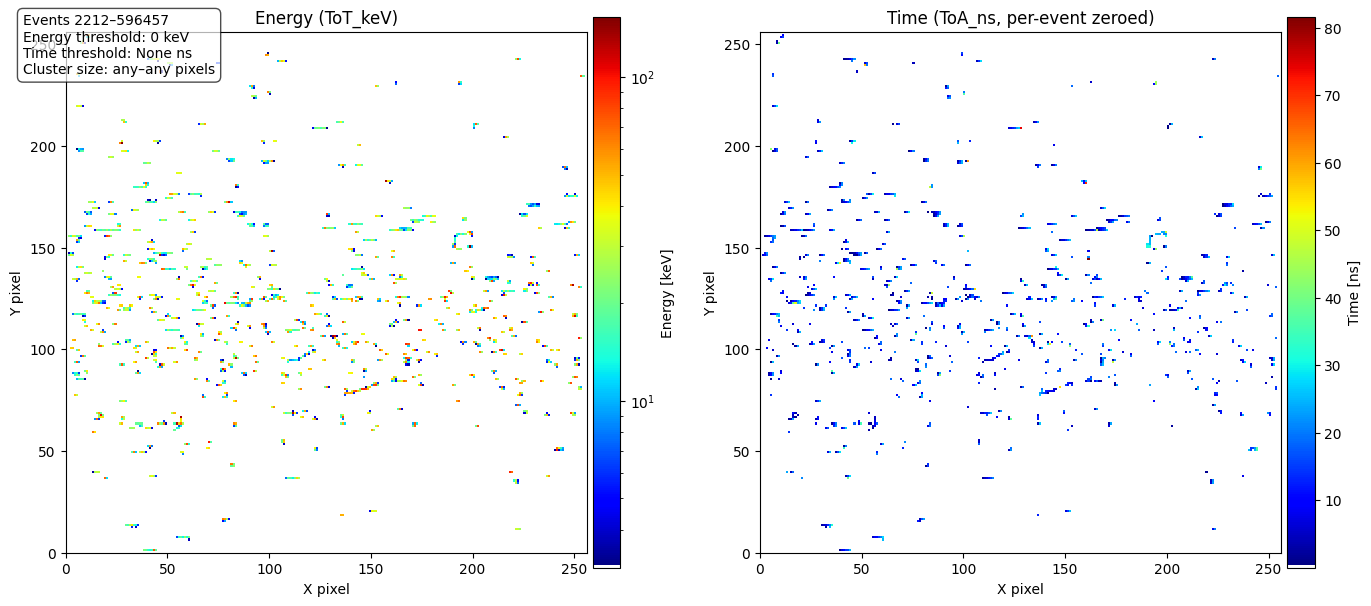


Cluster 2:
  x_spread        (cluster mean = 4.910, diff = 4.910)
  width           (cluster mean = 4.869, diff = 4.869)
  outer_pixels    (cluster mean = 2.990, diff = 2.990)
  Plotting 422 events from cluster 2...


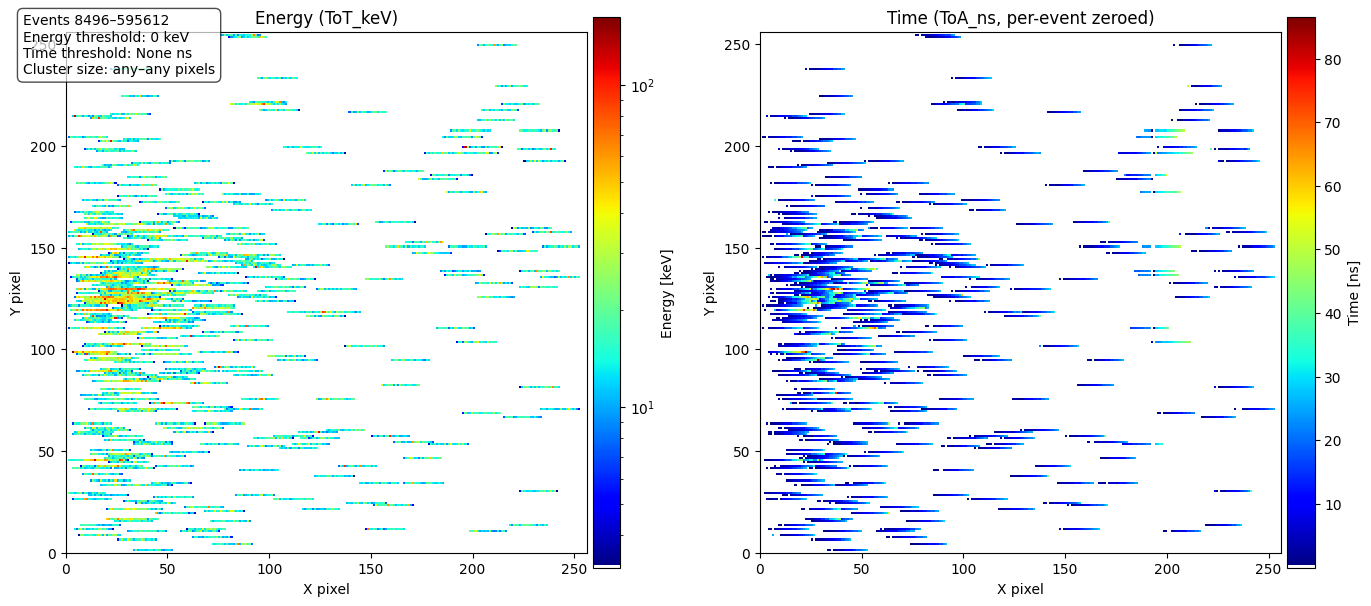


Cluster 3:
  aspect          (cluster mean = 7.784, diff = 7.784)
  width           (cluster mean = 4.864, diff = 4.864)
  x_spread        (cluster mean = 4.736, diff = 4.736)
  Plotting 323 events from cluster 3...


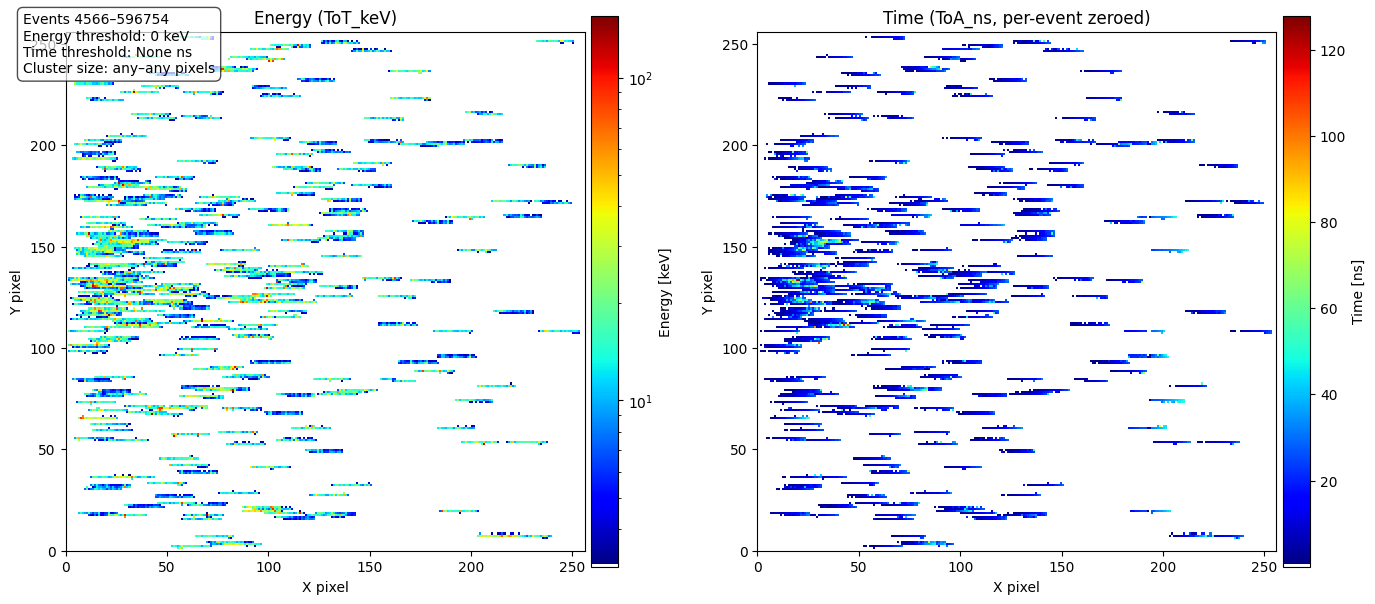


Cluster 4:
  width           (cluster mean = 4.875, diff = 4.875)
  x_spread        (cluster mean = 4.747, diff = 4.747)
  outer_pixels    (cluster mean = 4.156, diff = 4.156)
  Plotting 58 events from cluster 4...


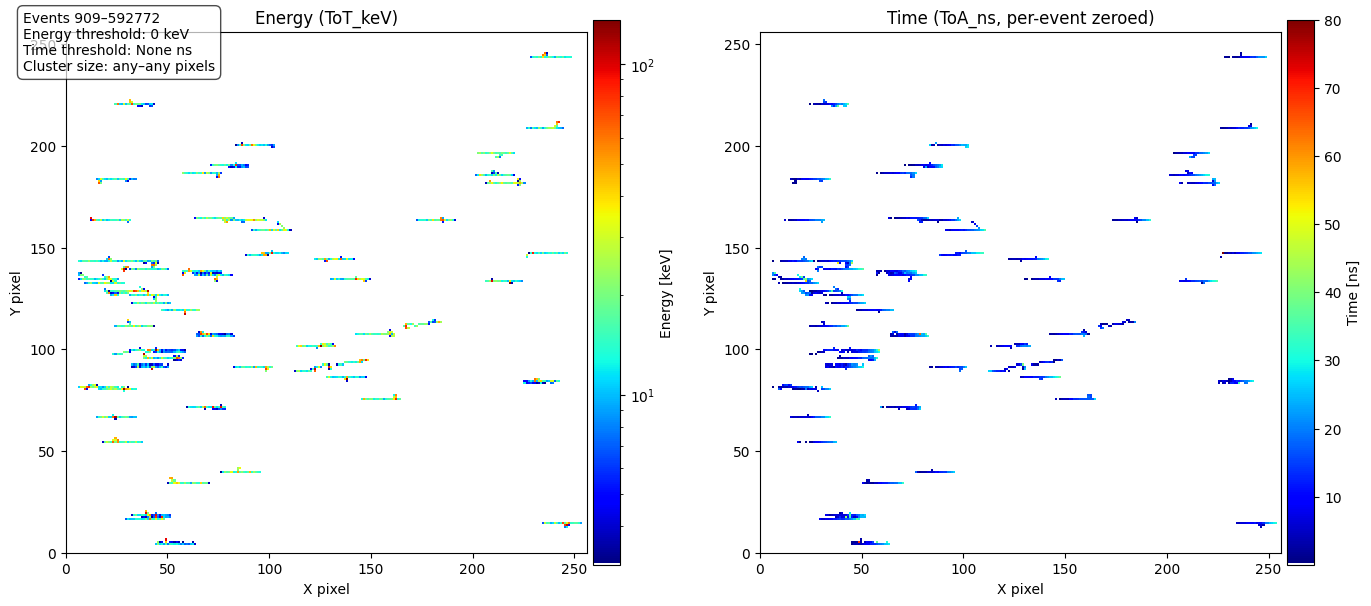

In [8]:
import numpy as np

# Optional: random sampling for DBSCAN
try:
    sample_size = input(f"Enter number of events to sample for DBSCAN (max {len(df_features)}): ")
    sample_size = int(sample_size)
except ValueError:
    print(f"Invalid input. Using all events ({len(df_features)})")
    sample_size = len(df_features)

if sample_size < len(df_features):
    np.random.seed(42)  # for reproducibility
    sampled_indices = np.random.choice(len(df_features), size=sample_size, replace=False)
    df_features_sampled = df_features.iloc[sampled_indices].copy()
    print(f"Using {sample_size} randomly sampled events for DBSCAN")
else:
    df_features_sampled = df_features.copy()
    print(f"Using all events ({len(df_features_sampled)}) for DBSCAN")


# Use sampled dataframe for DBSCAN features
feature_names = [col for col in df_features_sampled.columns if col not in ["Counter", "cluster"]]
X_p_sampled = df_features_sampled[feature_names].values
X_p_sampled = np.nan_to_num(X_p_sampled, nan=0.0, posinf=0.0, neginf=0.0)

# Scale features
from sklearn.preprocessing import StandardScaler
X_p_scaled_sampled = StandardScaler().fit_transform(X_p_sampled)


# Fit DBSCAN on sampled data
from sklearn.cluster import DBSCAN

try:
    eps = float(input("DBSCAN eps (neighborhood radius): ") or 1.5)
except ValueError:
    print("Invalid input. Using default eps = 1.5")
    eps = 1.5

try:
    min_samples = int(input("DBSCAN min_samples (minimum cluster size): ") or 50)
except ValueError:
    print("Invalid input. Using default min_samples = 50")
    min_samples = 50

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_p_scaled_sampled)
labels_dbscan = db.labels_

# Number of clusters
ndb_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

# Plotting
scatter = plt.scatter(X_p_scaled_sampled[:,0], X_p_scaled_sampled[:,1], c=labels_dbscan, cmap="tab10", s=10)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN clustering - " f"{ndb_clusters} clusters")
plt.xlim(-10, 250)
plt.ylim(-30, 80)

# Legend describing the number of events per cluster
unique_labels, counts = np.unique(labels_dbscan, return_counts=True)
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='C'+str(i), markersize=8)
           for i in range(len(unique_labels))]

# Format labels: replace -1 with "Noise"
legend_labels = [f"Noise = {cnt} points" if lab == -1 else f"Cluster {lab+1} = {cnt} points"
                 for lab, cnt in zip(unique_labels, counts)]

plt.legend(handles, legend_labels, bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

# Exclude noise points
cluster_labels = [lab for lab in set(labels_dbscan) if lab != -1]

# Global mean of features (scaled, using sampled data)
global_mean = np.mean(X_p_scaled_sampled, axis=0)


print("\nTop decisive features per DBSCAN cluster (sampled data):")

# Ensure proton_sampled has EventID
unique_events = proton_filtered["Counter"].unique()
event_map = {old: new for new, old in enumerate(unique_events)}
proton_filtered["EventID"] = proton_filtered["Counter"].map(event_map)

for cl in cluster_labels:
    # Select points in this cluster
    cluster_mask = labels_dbscan == cl
    cluster_points = X_p_scaled_sampled[cluster_mask]

    # Compute cluster centroid (mean feature vector)
    cluster_mean = cluster_points.mean(axis=0)

    # Compute absolute difference from global mean
    diffs = np.abs(cluster_mean - global_mean)

    # Top 3 features
    top_idx = np.argsort(diffs)[::-1][:3]

    print(f"\nCluster {cl+1}:")  # +1 to start cluster numbers at 1
    for i in top_idx:
        print(f"  {feature_names[i]:15s} (cluster mean = {cluster_mean[i]:.3f}, diff = {diffs[i]:.3f})")

    # Get the Counter IDs in this cluster
    cluster_events = df_features_sampled[cluster_mask]["Counter"].values

    # Map them to EventID in proton_sampled
    cluster_event_ids = [event_map[e] for e in cluster_events if e in event_map]

    if len(cluster_event_ids) > 0:
        # Only take the first 500 events
        sample_events = cluster_event_ids[:500]
        print(f"  Plotting {len(sample_events)} events from cluster {cl+1}...")
        clustr_pixel_df_input(proton_filtered, event=sample_events)
    else:
        print(f"  No events in proton_filtered for cluster {cl+1}")



## Gaussian Mixture Clustering, PCA Visualisation

Number of Gaussian clusters:  5


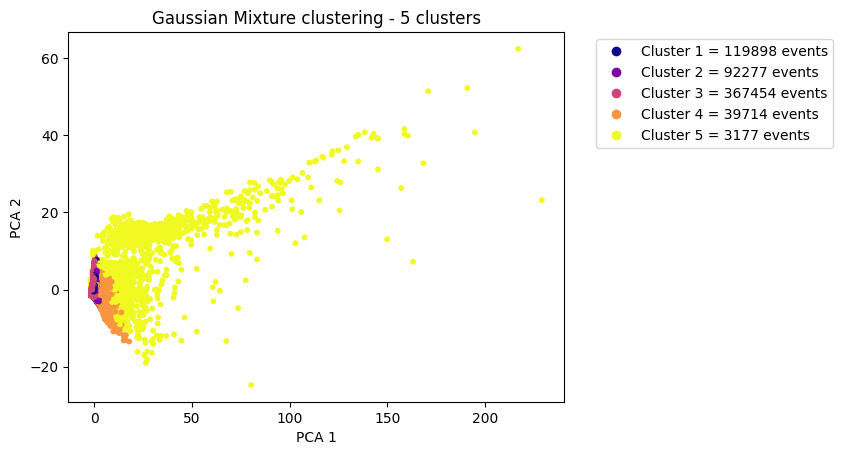


Top decisive features per Gaussian cluster (sampled data):

Cluster 1:
  y_spread        (mean = 0.680, diff = 0.680)
  x_spread        (mean = -0.476, diff = 0.476)
  width           (mean = -0.417, diff = 0.417)
  Plotting 500 events from cluster 1...


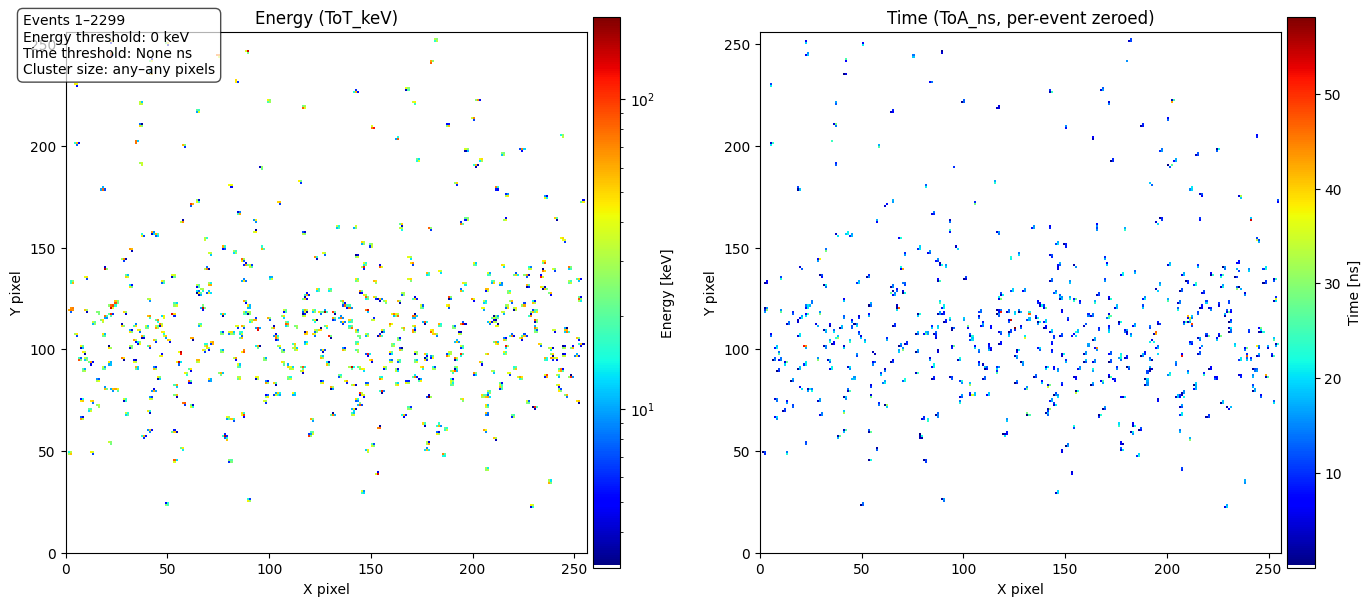


Cluster 2:
  aspect          (mean = 0.945, diff = 0.945)
  mean_energy     (mean = -0.651, diff = 0.651)
  y_spread        (mean = 0.568, diff = 0.568)
  Plotting 500 events from cluster 2...


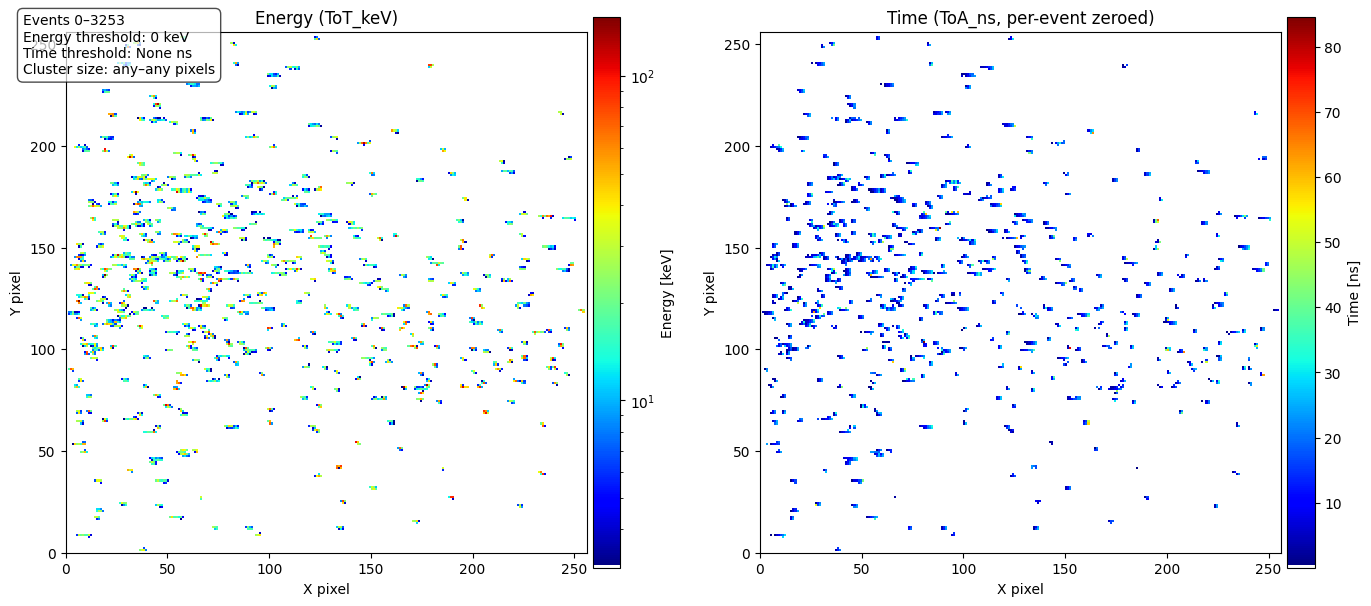


Cluster 3:
  y_spread        (mean = -0.540, diff = 0.540)
  aspect          (mean = -0.420, diff = 0.420)
  height          (mean = -0.370, diff = 0.370)
  Plotting 500 events from cluster 3...


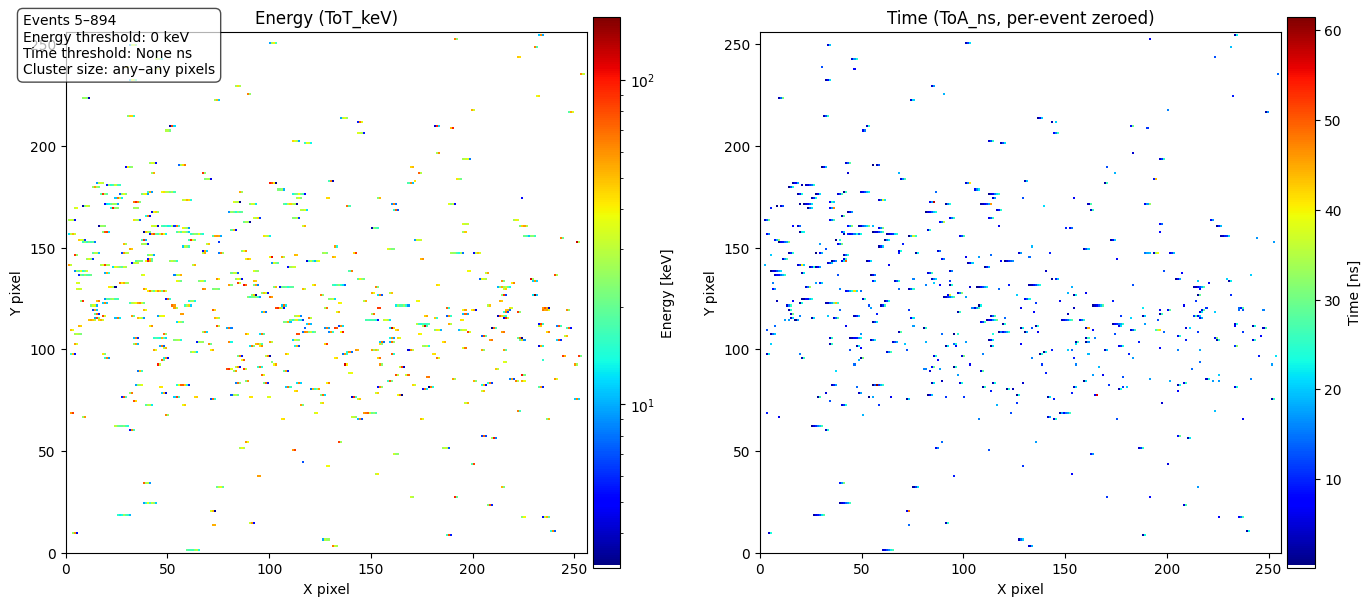


Cluster 4:
  width           (mean = 2.314, diff = 2.314)
  x_spread        (mean = 2.238, diff = 2.238)
  outer_pixels    (mean = 2.120, diff = 2.120)
  Plotting 500 events from cluster 4...


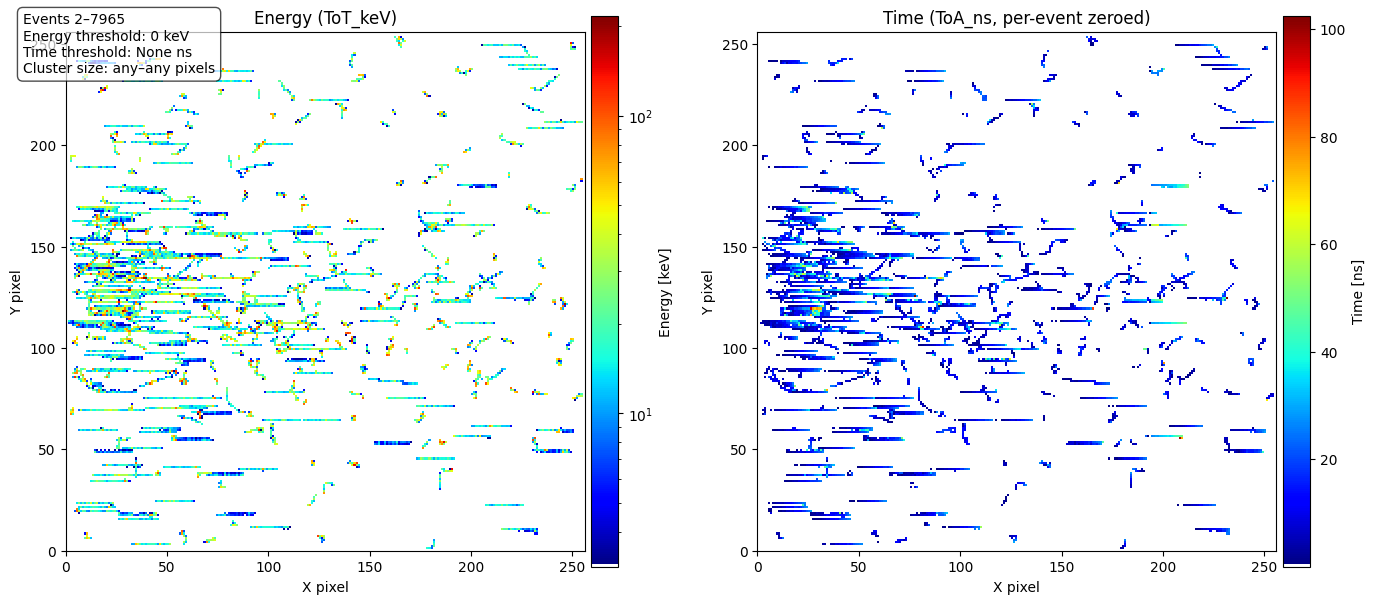


Cluster 5:
  height          (mean = 7.165, diff = 7.165)
  volcano_fraction (mean = 6.752, diff = 6.752)
  y_spread        (mean = 5.984, diff = 5.984)
  Plotting 500 events from cluster 5...


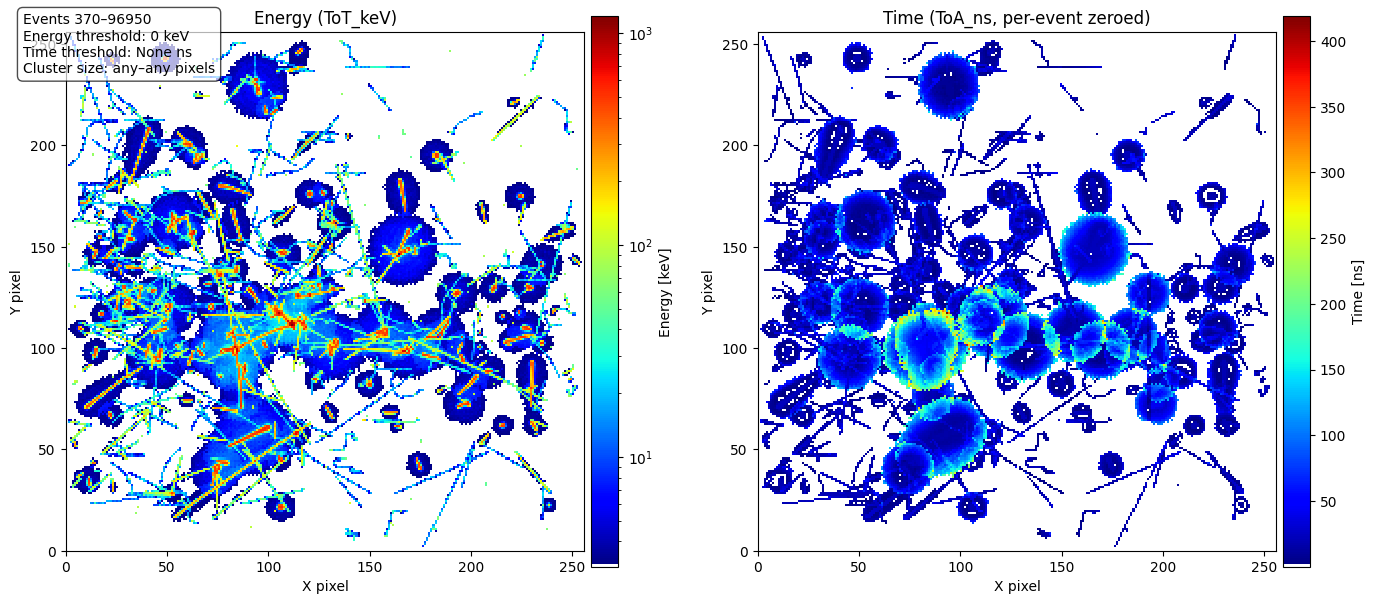

In [13]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Input number of Gaussian clusters
try:
    n_components = int(input("Number of Gaussian clusters: "))
except ValueError:
    print("Invalid input, defaulting to 3 clusters.")
    n_components = 3

# PCA for visualization
X_p_pca = PCA(n_components=2).fit_transform(X_p_scaled)

# Apply Gaussian mixture clustering
gmm = GaussianMixture(n_components, random_state=42)
labels_gmm = gmm.fit_predict(X_p_scaled)

# Plotting
scatter = plt.scatter(X_p_pca[:,0], X_p_pca[:,1], c=labels_gmm, cmap="plasma", s=10)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Gaussian Mixture clustering - " f"{n_components} clusters")

# Legend
handles, _ = scatter.legend_elements()
unique_labels, counts = np.unique(labels_gmm, return_counts=True)
legend_labels = [f"Cluster {lab+1} = {cnt} events" for lab, cnt in zip(unique_labels, counts)]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Global mean in scaled feature space
global_mean = np.mean(X_p_scaled, axis=0)


print("\nTop decisive features per Gaussian cluster (sampled data):")

# Ensure proton_sampled has EventID
unique_events = proton_filtered["Counter"].unique()
event_map = {old: new for new, old in enumerate(unique_events)}
proton_filtered["EventID"] = proton_filtered["Counter"].map(event_map)

cluster_labels = np.unique(labels_gmm)
for cl in cluster_labels:
    # Select points in this cluster
    cluster_mask = labels_gmm == cl
    cluster_points = X_p_scaled[cluster_mask]

    # Compute cluster centroid (mean feature vector)
    cluster_mean = cluster_points.mean(axis=0)

    # Compute absolute difference from global mean
    diffs = np.abs(gmm.means_[cl] - global_mean)

    # Top 3 features
    top_idx = np.argsort(diffs)[::-1][:3]

    print(f"\nCluster {cl+1}:")  # +1 to start cluster numbers at 1
    for i in top_idx:
        print(f"  {feature_names[i]:15s} (mean = {gmm.means_[cl,i]:.3f}, diff = {diffs[i]:.3f})")

    # Get the Counter IDs in this cluster
    cluster_events = df_features[cluster_mask]["Counter"].values

    # Map them to EventID in proton_sampled
    cluster_event_ids = [event_map[e] for e in cluster_events if e in event_map]

    if len(cluster_event_ids) > 0:
        # Only take the first 500 events
        sample_events = cluster_event_ids[:500]
        print(f"  Plotting {len(sample_events)} events from cluster {cl+1}...")
        clustr_pixel_df_input(proton_filtered, event=sample_events)
    else:
        print(f"  No events in proton_filtered for cluster {cl+1}")




## Bayesian Gaussian Mixture clustering, PCA visualisation

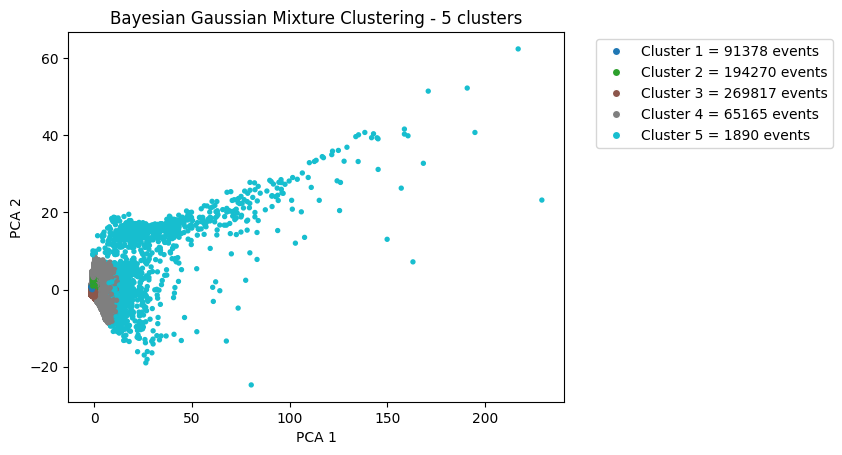

In [20]:
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Bayesian Gaussian Mixture
bgmm = BayesianGaussianMixture(
    n_components=5,                                         # maximum number of Gaussian clusters
    covariance_type='spherical',                            # each Gaussian has a spherical covariance matrix
    weight_concentration_prior_type='dirichlet_process',    # allows the model to automatically turn off components if they’re unnecessary
    weight_concentration_prior=1e-2,                        # small values push the model to favor fewer clusters
    mean_precision_prior=1.0,                               # controls how tightly cluster means are pulled toward the global mean of the data
    reg_covar=1e-6,                                         # adds a tiny value to the diagonal of covariance matrices
    max_iter=300,                                           # maximum number of iterations for the EM (Expectation-Maximization) algorithm
    tol=1e-3,                                               # convergence threshold for EM
    init_params='kmeans',                                   # how initial cluster means are chosen
    n_init=1,                                               # number of times to run EM with different initializations
    random_state=42
)

X_reduced = PCA(n_components=10, random_state=42).fit_transform(X_p_scaled)
labels_bgmm = bgmm.fit_predict(X_reduced)

# Identify active clusters
unique_labels, counts = np.unique(labels_bgmm, return_counts=True)
active_labels = [lab for lab, cnt in zip(unique_labels, counts) if lab != -1]  # -1 = noise
n_active_clusters = len(active_labels)


# Plotting
scatter = plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels_bgmm, cmap="tab10", s=8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"Bayesian Gaussian Mixture Clustering - {n_active_clusters} clusters")

# Legend
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)), markersize=6)
           for l in active_labels]
legend_labels = [f"Cluster {l+1} = {counts[i]} events" 
                 for i, l in enumerate(unique_labels) if l != -1]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

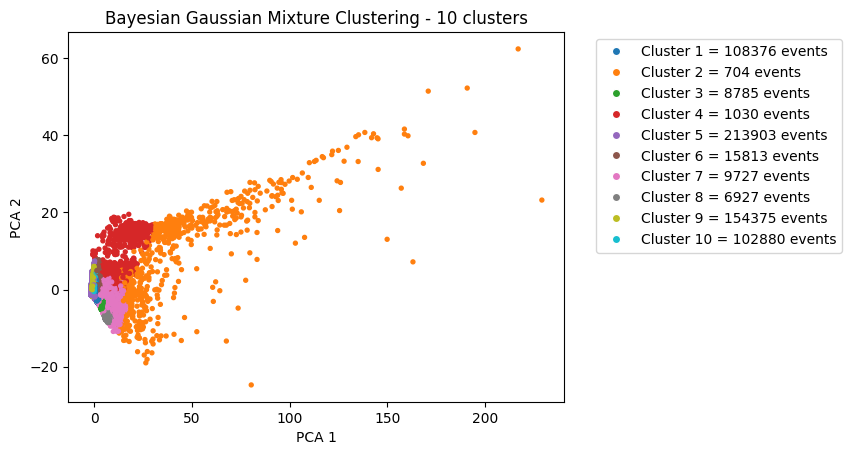


Cluster 1:
  aspect          (mean = 0.867, diff = 0.867)
  mean_energy     (mean = -0.607, diff = 0.607)
  y_spread        (mean = 0.564, diff = 0.564)
  Plotting 500 events from cluster 1...


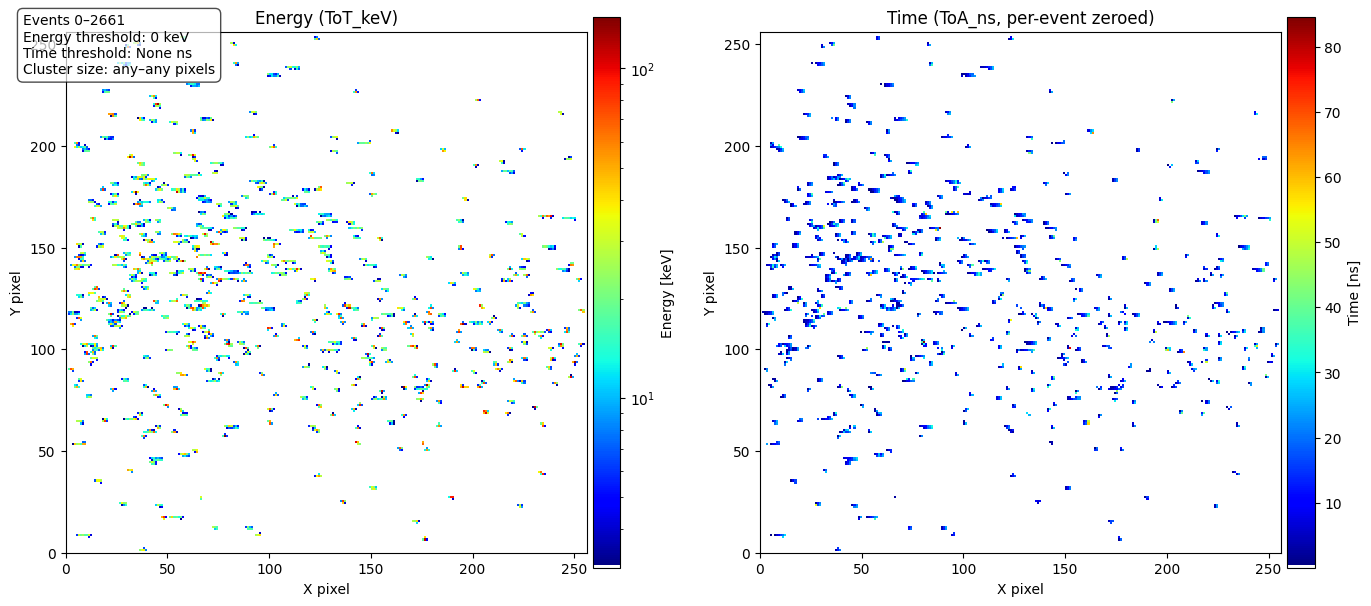


Cluster 2:
  num_hits        (mean = 18.634, diff = 18.634)
  total_energy    (mean = 18.287, diff = 18.287)
  height          (mean = 17.487, diff = 17.487)
  Plotting 500 events from cluster 2...


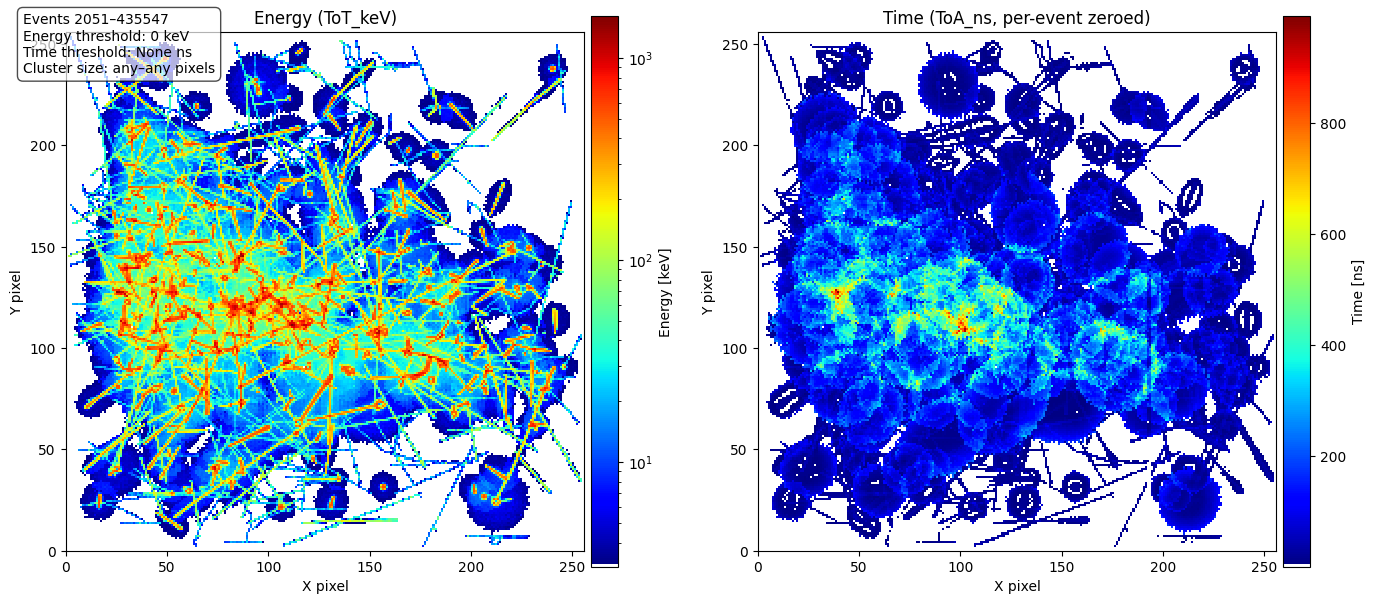


Cluster 3:
  x_spread        (mean = 4.848, diff = 4.848)
  width           (mean = 4.780, diff = 4.780)
  outer_pixels    (mean = 2.980, diff = 2.980)
  Plotting 500 events from cluster 3...


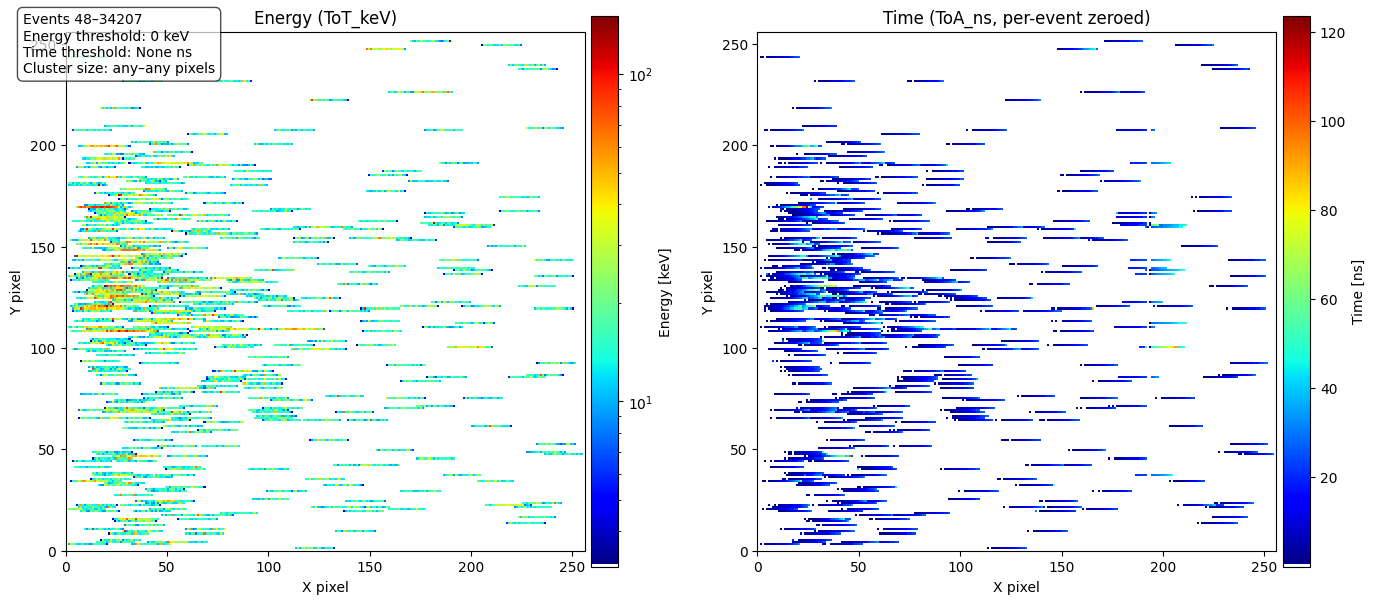


Cluster 4:
  volcano_fraction (mean = 14.112, diff = 14.112)
  max_energy      (mean = 8.536, diff = 8.536)
  height          (mean = 5.268, diff = 5.268)
  Plotting 500 events from cluster 4...


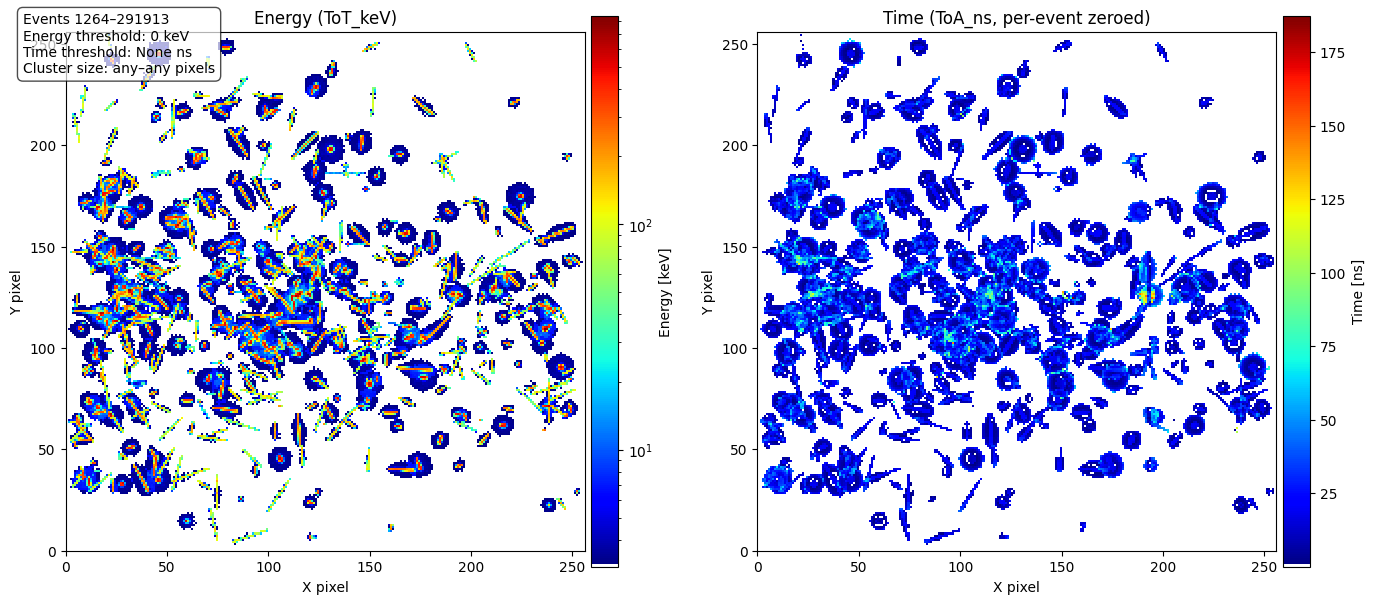


Cluster 5:
  y_spread        (mean = -0.540, diff = 0.540)
  aspect          (mean = -0.420, diff = 0.420)
  mean_energy     (mean = -0.400, diff = 0.400)
  Plotting 500 events from cluster 5...


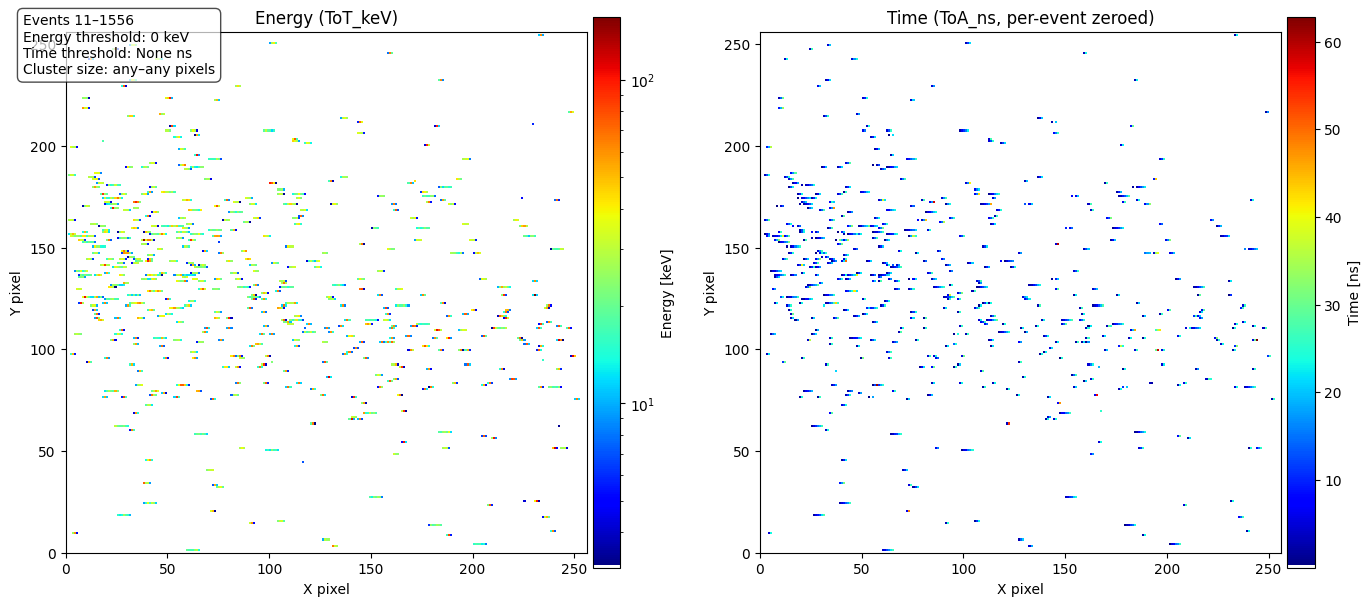


Cluster 6:
  y_spread        (mean = 1.520, diff = 1.520)
  height          (mean = 1.309, diff = 1.309)
  max_energy      (mean = 1.154, diff = 1.154)
  Plotting 500 events from cluster 6...


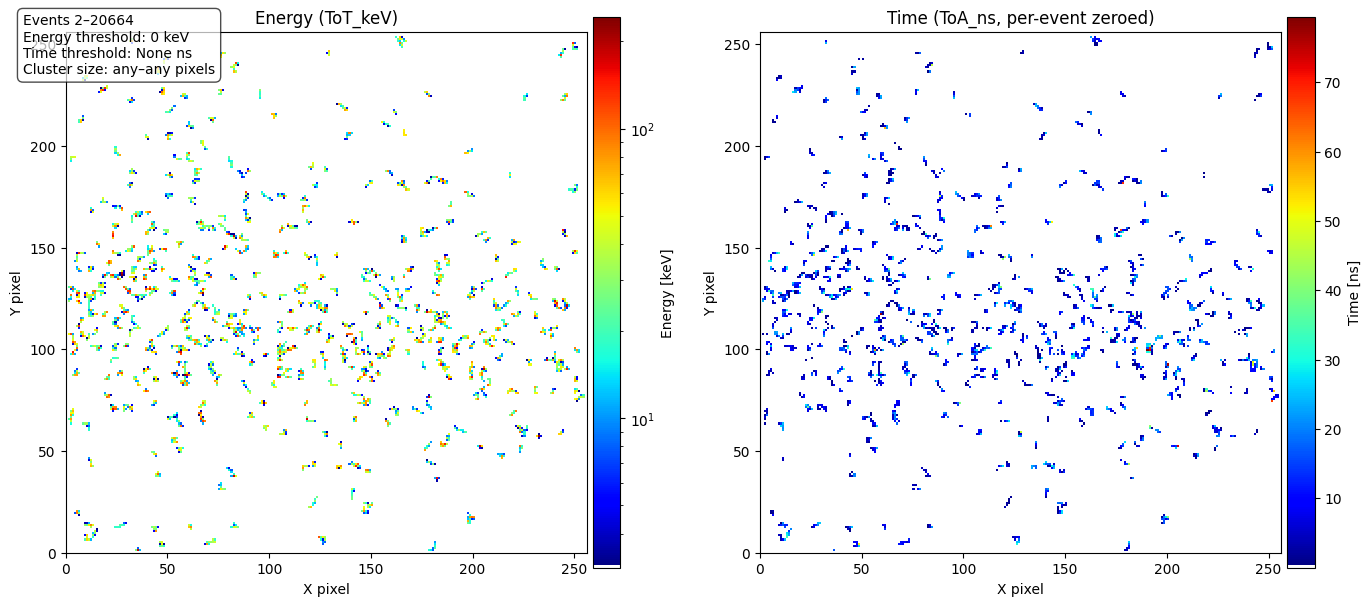


Cluster 7:
  height          (mean = 3.130, diff = 3.130)
  y_spread        (mean = 3.048, diff = 3.048)
  outer_pixels    (mean = 2.574, diff = 2.574)
  Plotting 500 events from cluster 7...


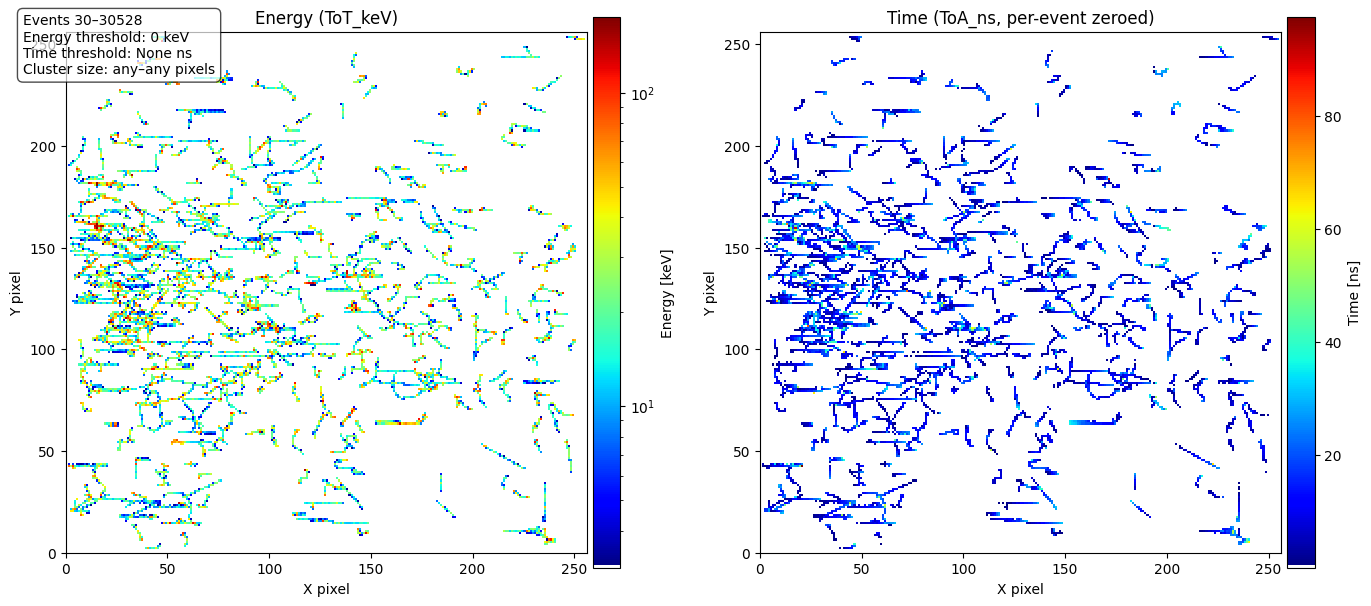


Cluster 8:
  aspect          (mean = 7.669, diff = 7.669)
  width           (mean = 4.763, diff = 4.763)
  x_spread        (mean = 4.684, diff = 4.684)
  Plotting 500 events from cluster 8...


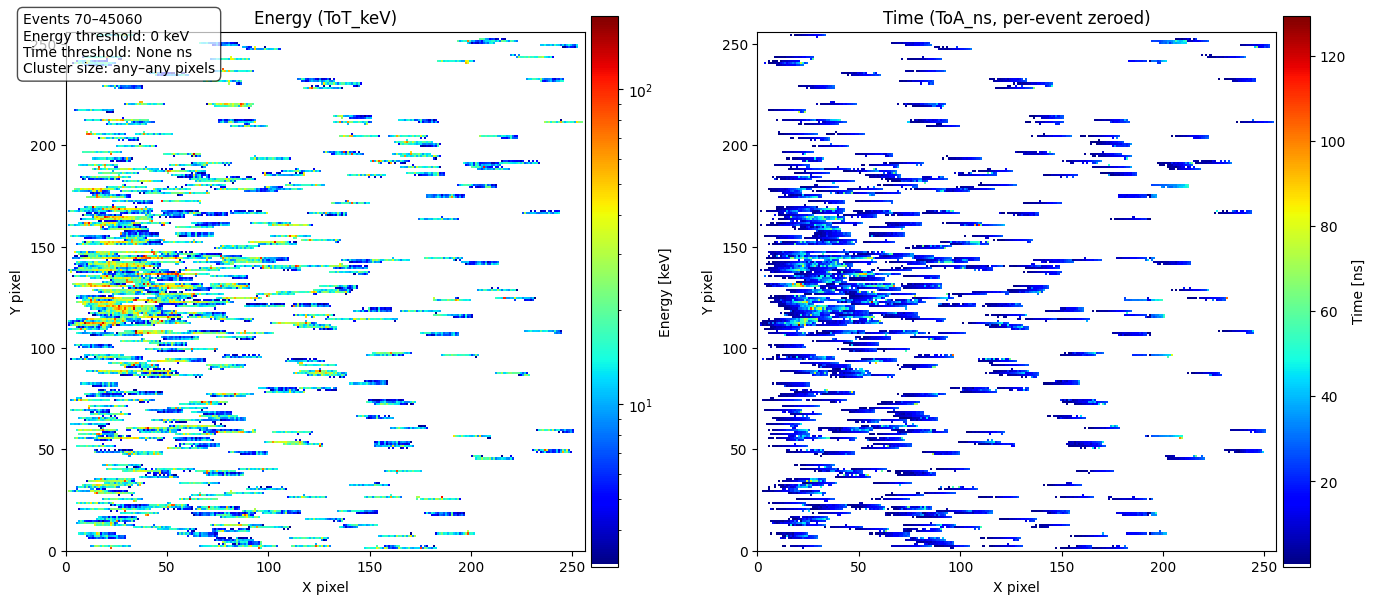


Cluster 9:
  mean_energy     (mean = 1.113, diff = 1.113)
  y_spread        (mean = -0.540, diff = 0.540)
  outer_pixels    (mean = -0.483, diff = 0.483)
  Plotting 500 events from cluster 9...


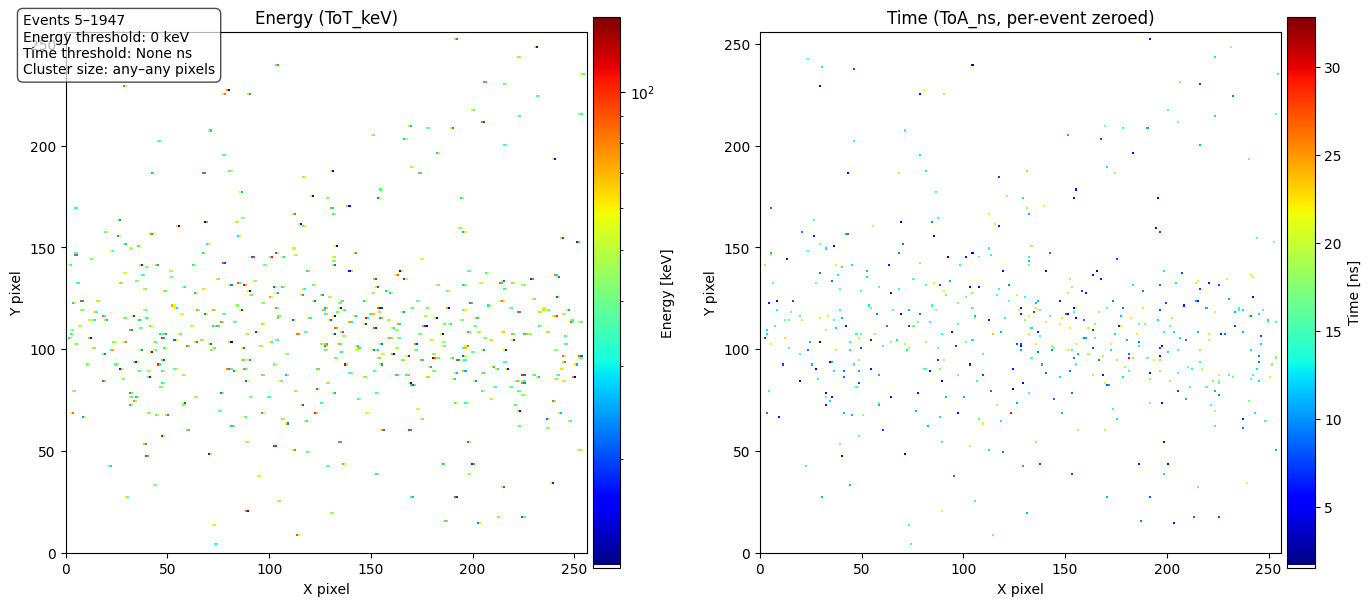


Cluster 10:
  y_spread        (mean = 0.703, diff = 0.703)
  x_spread        (mean = -0.511, diff = 0.511)
  width           (mean = -0.459, diff = 0.459)
  Plotting 500 events from cluster 10...


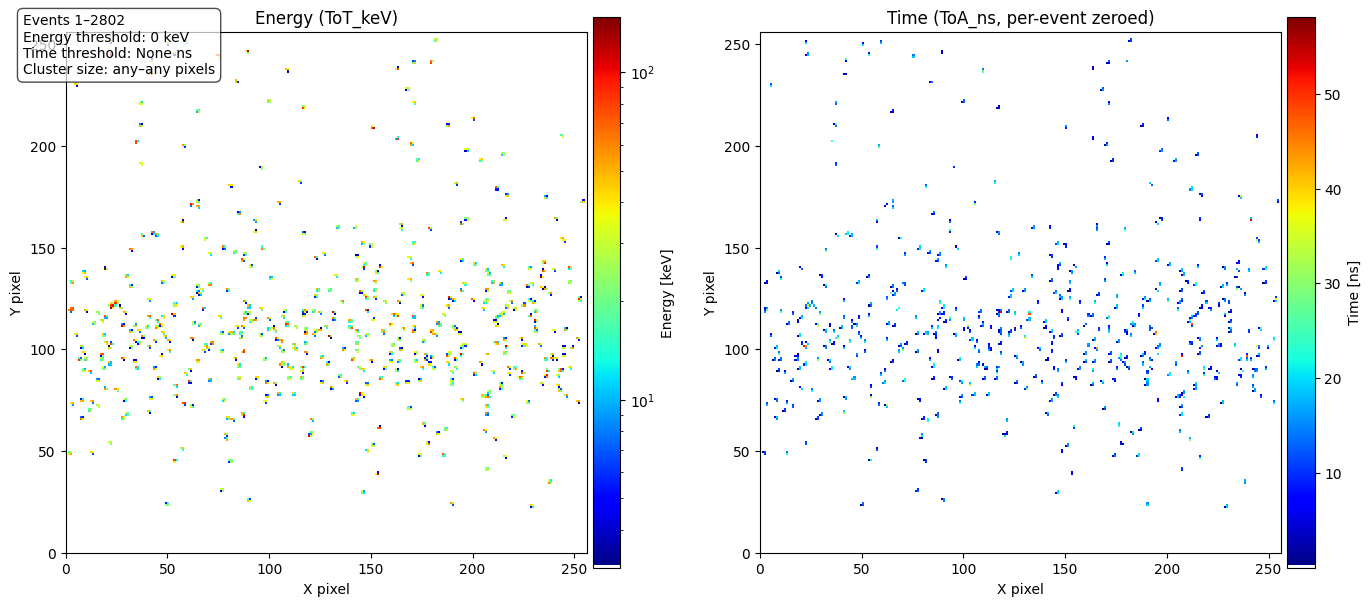


Top decisive features per Bayesian GMM cluster:

Cluster 1:
  aspect          (mean = 0.867, diff = 0.867)
  mean_energy     (mean = -0.607, diff = 0.607)
  y_spread        (mean = 0.564, diff = 0.564)
  Plotting 500 events from cluster 1...


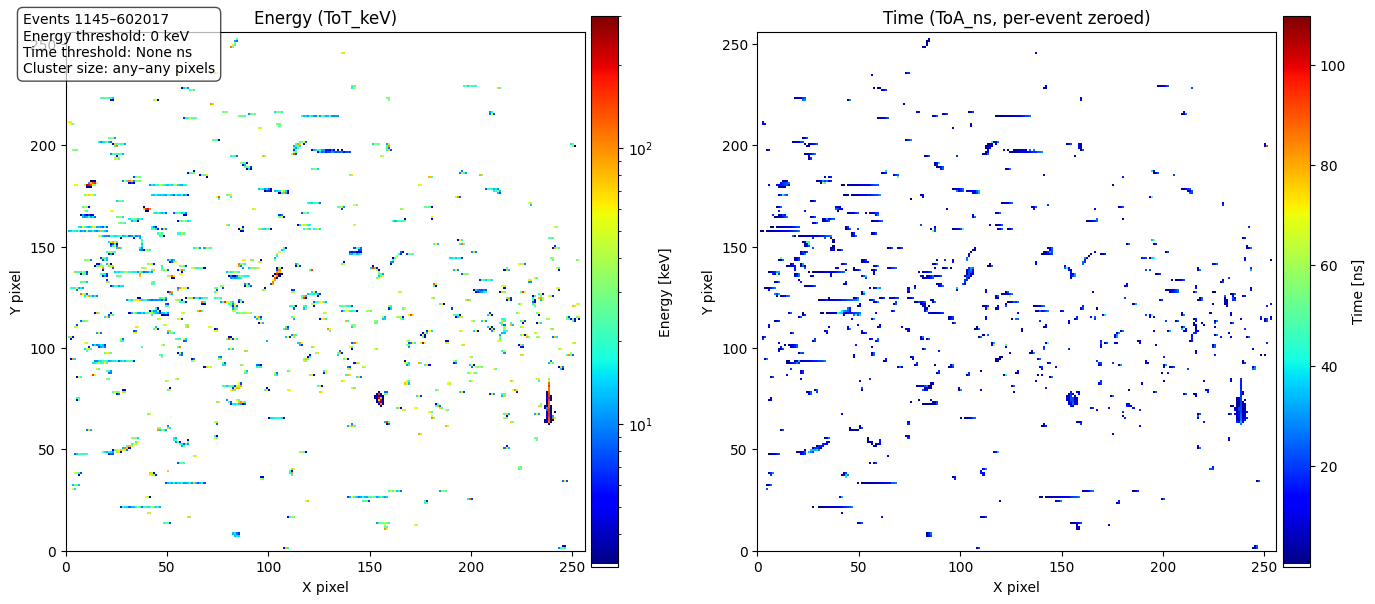


Cluster 2:
  num_hits        (mean = 18.634, diff = 18.634)
  total_energy    (mean = 18.287, diff = 18.287)
  height          (mean = 17.487, diff = 17.487)
  Plotting 500 events from cluster 2...


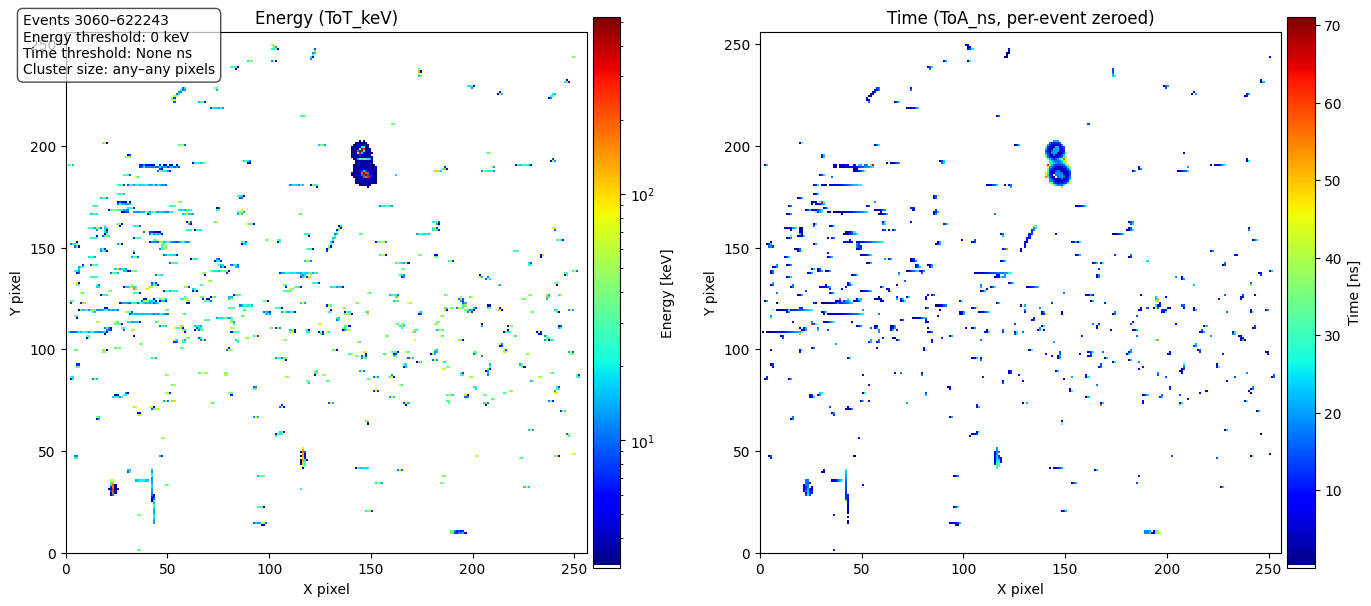


Cluster 3:
  x_spread        (mean = 4.848, diff = 4.848)
  width           (mean = 4.780, diff = 4.780)
  outer_pixels    (mean = 2.980, diff = 2.980)
  Plotting 500 events from cluster 3...


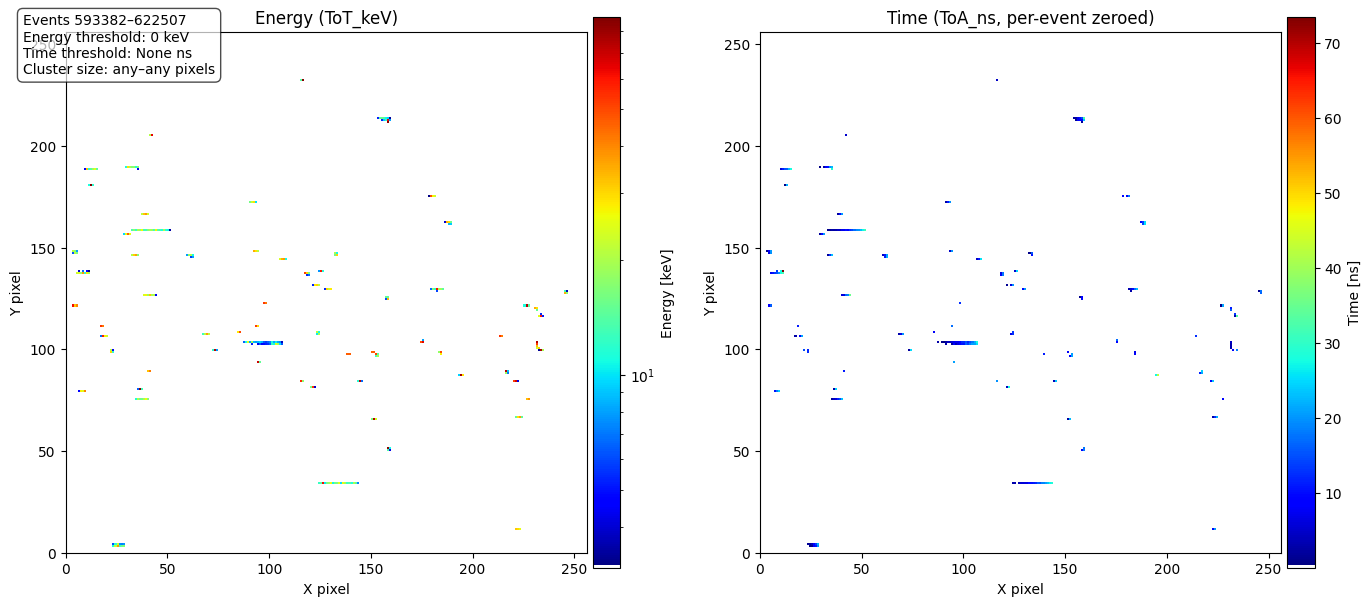


Cluster 4:
  volcano_fraction (mean = 14.112, diff = 14.112)
  max_energy      (mean = 8.536, diff = 8.536)
  height          (mean = 5.268, diff = 5.268)
  Plotting 500 events from cluster 4...


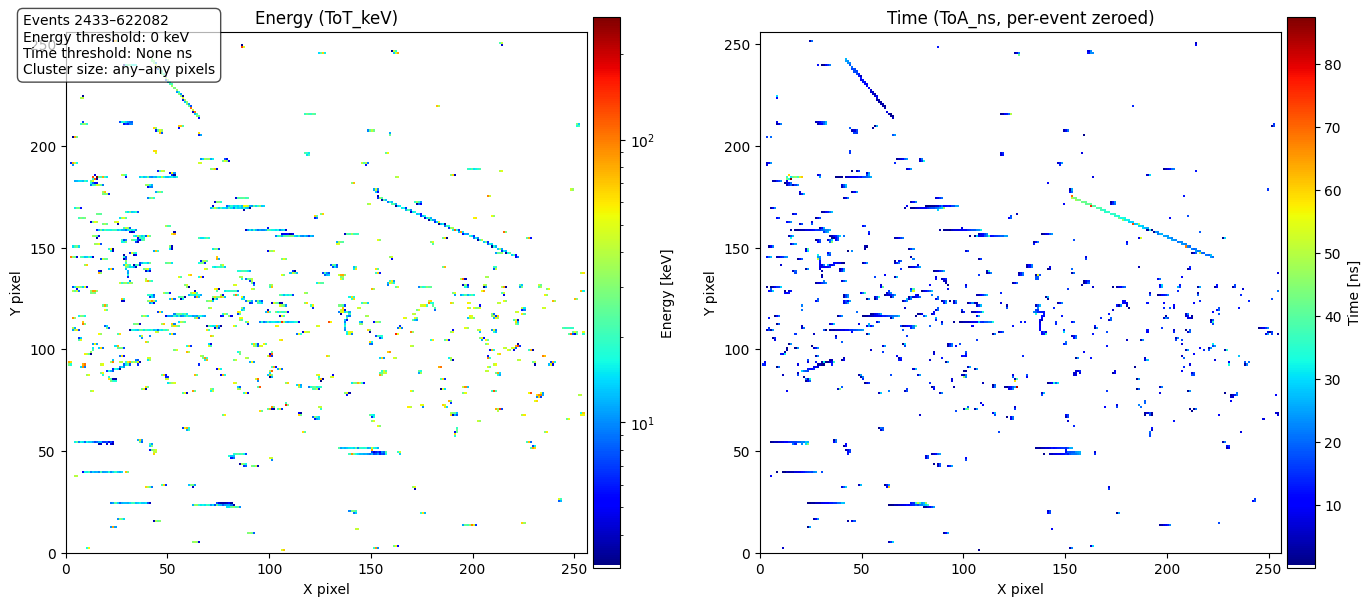


Cluster 5:
  y_spread        (mean = -0.540, diff = 0.540)
  aspect          (mean = -0.420, diff = 0.420)
  mean_energy     (mean = -0.400, diff = 0.400)
  Plotting 500 events from cluster 5...


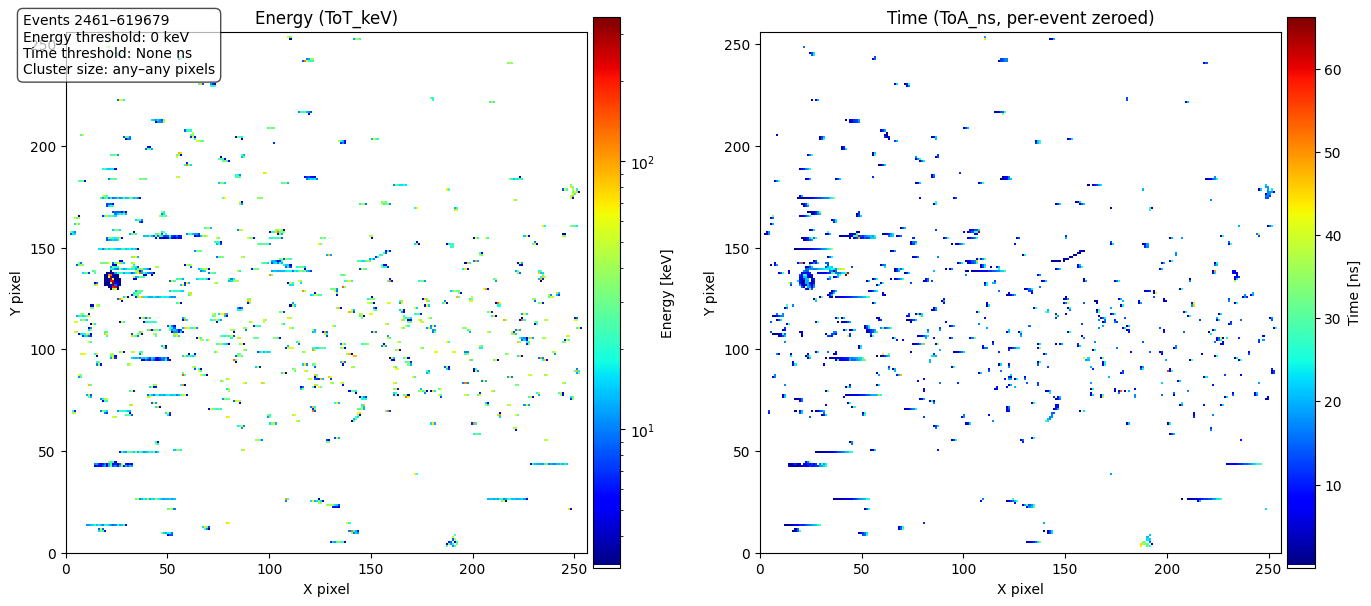


Cluster 6:
  y_spread        (mean = 1.520, diff = 1.520)
  height          (mean = 1.309, diff = 1.309)
  max_energy      (mean = 1.154, diff = 1.154)
  Plotting 500 events from cluster 6...


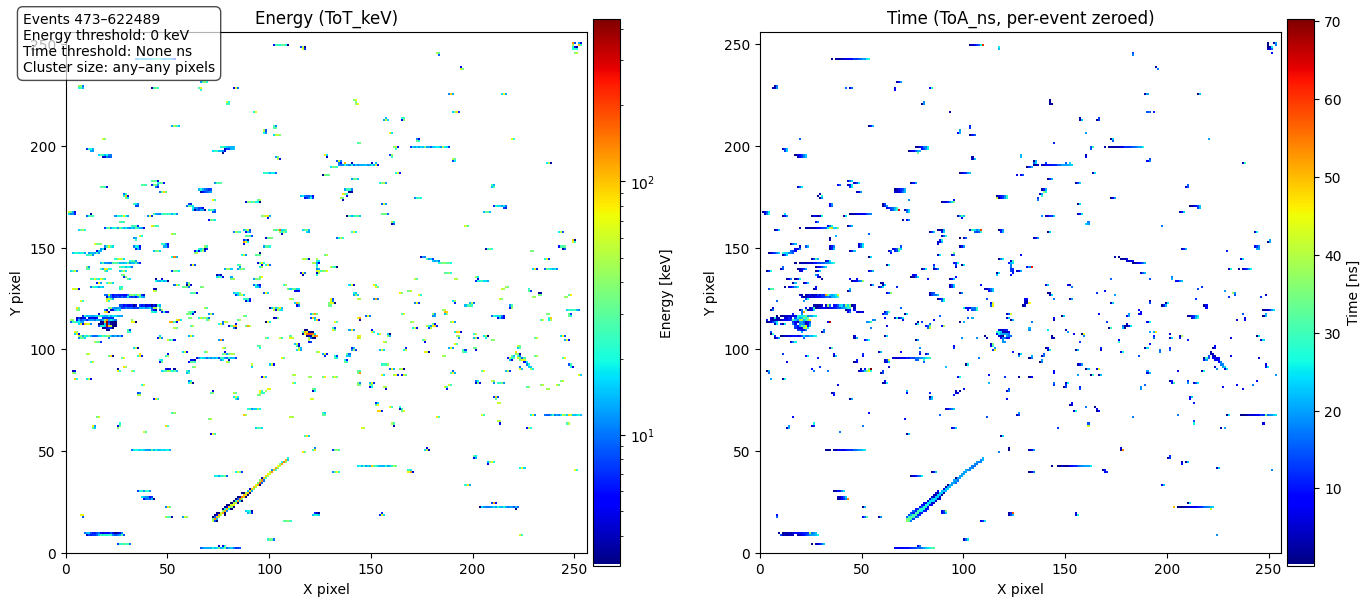


Cluster 7:
  height          (mean = 3.130, diff = 3.130)
  y_spread        (mean = 3.048, diff = 3.048)
  outer_pixels    (mean = 2.574, diff = 2.574)
  Plotting 500 events from cluster 7...


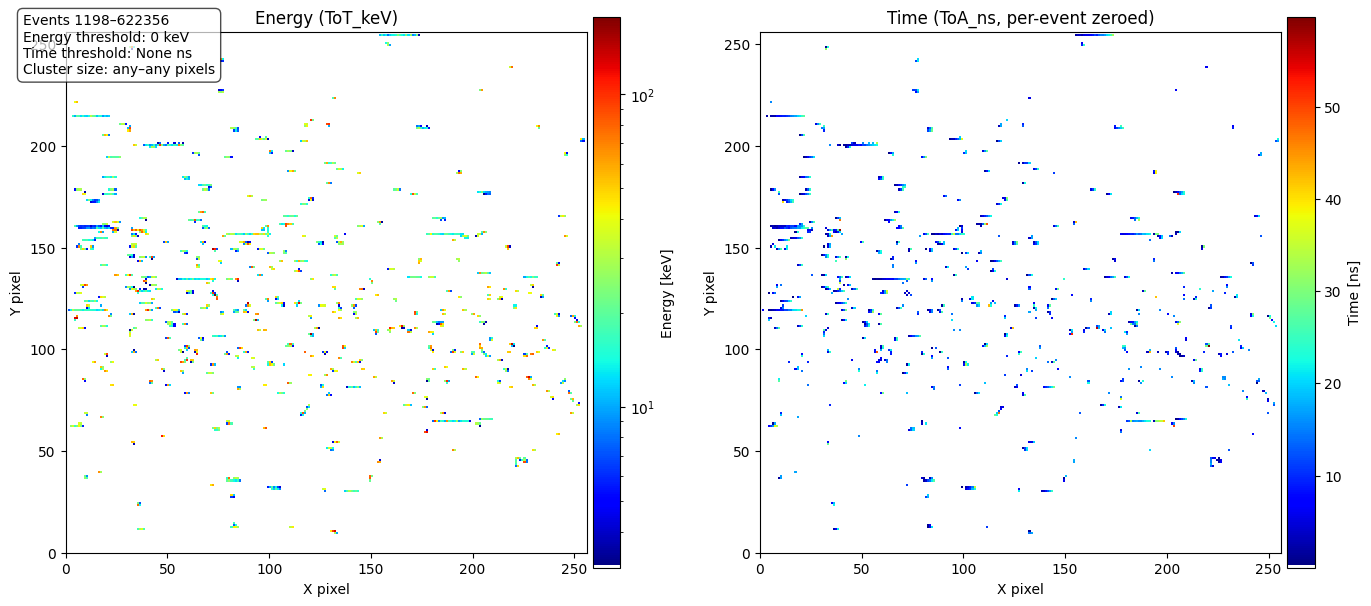


Cluster 8:
  aspect          (mean = 7.669, diff = 7.669)
  width           (mean = 4.763, diff = 4.763)
  x_spread        (mean = 4.684, diff = 4.684)
  Plotting 500 events from cluster 8...


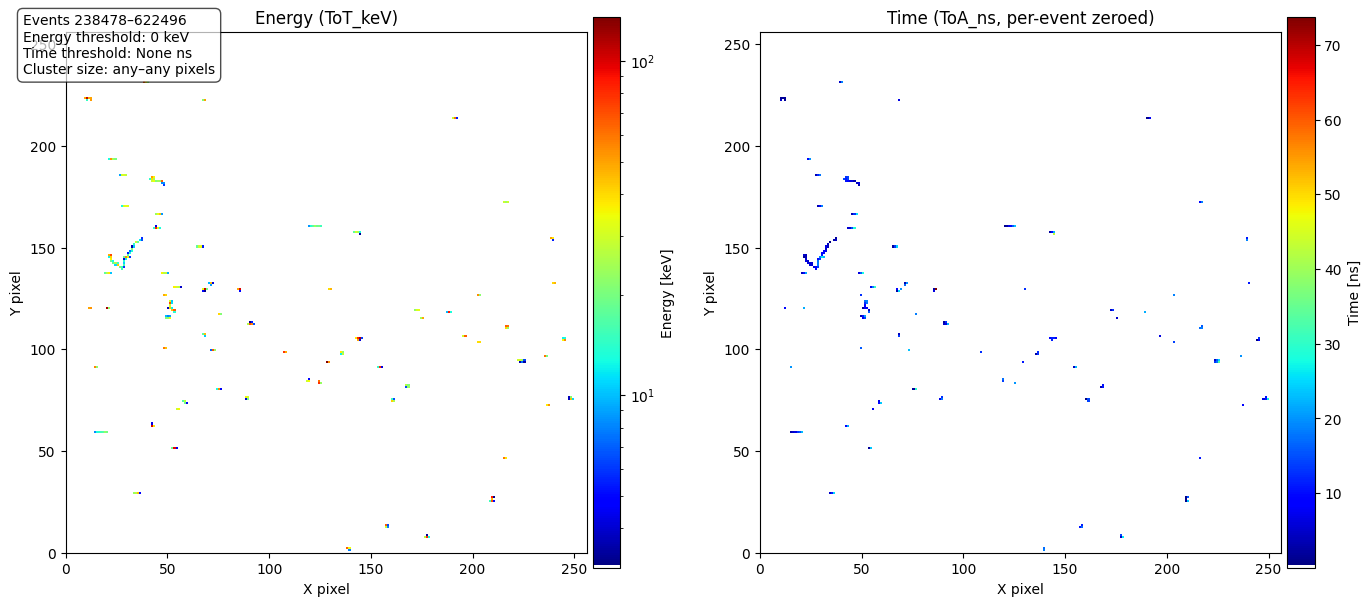


Cluster 9:
  mean_energy     (mean = 1.113, diff = 1.113)
  y_spread        (mean = -0.540, diff = 0.540)
  outer_pixels    (mean = -0.483, diff = 0.483)
  Plotting 500 events from cluster 9...


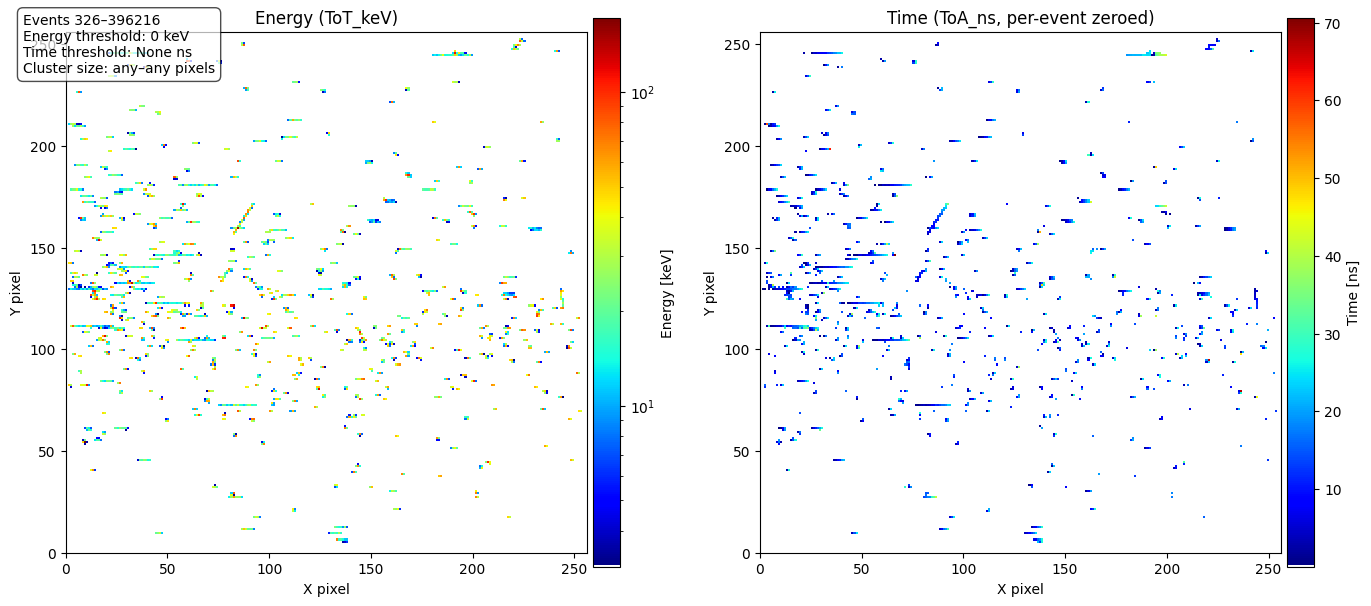


Cluster 10:
  y_spread        (mean = 0.703, diff = 0.703)
  x_spread        (mean = -0.511, diff = 0.511)
  width           (mean = -0.459, diff = 0.459)
  Plotting 500 events from cluster 10...


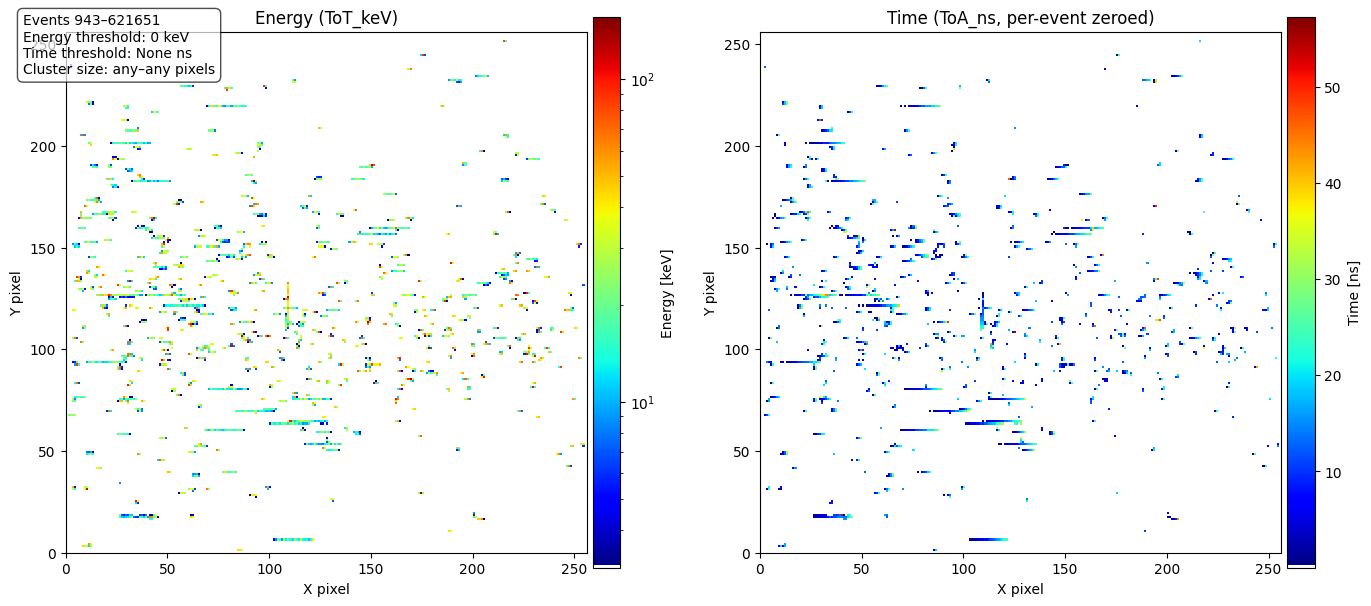

In [18]:
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Bayesian Gaussian Mixture
bgmm = BayesianGaussianMixture(
    n_components=10,                                      # maximum number of Gaussian clusters
    covariance_type='diag',#'full', 'tied', 'spherical'   # each Gaussian has a diagonal covariance matrix
    weight_concentration_prior_type='dirichlet_process',  # allows the model to automatically turn off components if they’re unnecessary
    weight_concentration_prior=1e-4,                      # small values push the model to favor fewer clusters
    mean_precision_prior=1.0,                             # controls how tightly cluster means are pulled toward the global mean of the data
    reg_covar=1e-6,                                       # adds a tiny value to the diagonal of covariance matrices
    max_iter=1000,                                        # maximum number of iterations for the EM (Expectation-Maximization) algorithm
    tol=1e-4,                                             # convergence threshold for EM
    init_params='kmeans', #'random'                       # how initial cluster means are chosen
    n_init=3,                                             # number of times to run EM with different initializations
    random_state=42
)

labels_bgmm = bgmm.fit_predict(X_p_scaled)

# Identify active clusters
unique_labels, counts = np.unique(labels_bgmm, return_counts=True)
active_labels = [lab for lab, cnt in zip(unique_labels, counts) if lab != -1]  # -1 = noise
n_active_clusters = len(active_labels)


# Plotting
scatter = plt.scatter(X_p_pca[:,0], X_p_pca[:,1], c=labels_bgmm, cmap="tab10", s=8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"Bayesian Gaussian Mixture Clustering - {n_active_clusters} clusters")

# Legend
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)), markersize=6)
           for l in active_labels]
legend_labels = [f"Cluster {l+1} = {counts[i]} events" 
                 for i, l in enumerate(unique_labels) if l != -1]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


# Ensure proton_sampled has EventID
global_mean = np.mean(X_p_scaled, axis=0)
unique_events = proton_filtered["Counter"].unique()
event_map = {old: new for new, old in enumerate(unique_events)}
proton_filtered["EventID"] = proton_filtered["Counter"].map(event_map)

cluster_labels = np.unique(labels_bgmm)
for cl in cluster_labels:
    # Select points in this cluster
    cluster_mask = labels_bgmm == cl
    cluster_points = X_p_scaled[cluster_mask]

    # Compute cluster centroid (mean feature vector)
    cluster_mean = cluster_points.mean(axis=0)

    # Compute absolute difference from global mean
    diffs = np.abs(bgmm.means_[cl] - global_mean)

    # Top 3 features
    top_idx = np.argsort(diffs)[::-1][:3]

    print(f"\nCluster {cl+1}:")  # +1 to start cluster numbers at 1
    for i in top_idx:
        print(f"  {feature_names[i]:15s} (mean = {bgmm.means_[cl,i]:.3f}, diff = {diffs[i]:.3f})")

    # Get the Counter IDs in this cluster
    cluster_events = df_features[cluster_mask]["Counter"].values

    # Map them to EventID in proton_sampled
    cluster_event_ids = [event_map[e] for e in cluster_events if e in event_map]

    if len(cluster_event_ids) > 0:
        # Only take the first 500 events
        sample_events = cluster_event_ids[:500]
        print(f"  Plotting {len(sample_events)} events from cluster {cl+1}...")
        clustr_pixel_df_input(proton_filtered, event=sample_events)
    else:
        print(f"  No events in proton_filtered for cluster {cl+1}")



## K-means Clustering, UMAP Visualisation

Enter number of events to sample for UMAP (max 622520):  20000


Using 20000 randomly sampled events for UMAP


Number of K-Means clusters:  5
Number of neighbors for UMAP:  50


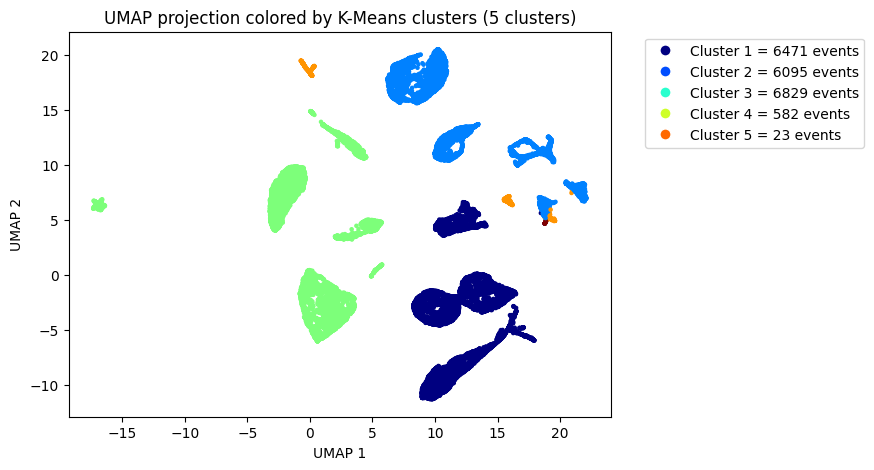

In [25]:
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


# Optional subsampling of data
try:
    sample_size = int(input(f"Enter number of events to sample for UMAP (max {len(df_features)}): "))
except ValueError:
    print(f"Invalid input. Using all events ({len(df_features)})")
    sample_size = len(df_features)

if sample_size < len(df_features):
    np.random.seed(42)
    sampled_indices = np.random.choice(len(df_features), size=sample_size, replace=False)
    df_features_sampled = df_features.iloc[sampled_indices].copy()
    print(f"Using {sample_size} randomly sampled events for UMAP")
else:
    df_features_sampled = df_features.copy()
    print(f"Using all events ({len(df_features_sampled)}) for UMAP")

# Feature matrix
feature_names = df_features_sampled.columns.drop("Counter")
X_p_sampled = df_features_sampled[feature_names].values
X_p_sampled = np.nan_to_num(X_p_sampled, nan=0.0, posinf=0.0, neginf=0.0)

# Scale features
from sklearn.preprocessing import StandardScaler
X_p_scaled_sampled = StandardScaler().fit_transform(X_p_sampled)


# K-Means clustering
try:
    n_clusters = int(input("Number of K-Means clusters: "))
except ValueError:
    print("Invalid input, defaulting to 3 clusters.")
    n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X_p_scaled_sampled)


# UMAP projection
try:
    n_neighbors = int(input("Number of neighbors for UMAP: "))
except ValueError:
    print("Invalid input, defaulting to 50 neighbors.")
    n_neighbors = 50

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.1,
    n_components=2,
    n_jobs=-1       
)

embedding = reducer.fit_transform(X_p_scaled_sampled)


# Plotting
plt.figure(figsize=(7,5))
scatter = plt.scatter(embedding[:,0], embedding[:,1], c=labels_kmeans, cmap="jet", s=5)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title(f"UMAP projection colored by K-Means clusters ({n_clusters} clusters)")

# Legend showing cluster sizes
unique_labels, counts = np.unique(labels_kmeans, return_counts=True)

import matplotlib as mpl
cmap = plt.colormaps.get_cmap("jet")  
colors = [cmap(i / len(unique_labels)) for i in range(len(unique_labels))]

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[i],
        markersize=8
    )
    for i in range(len(unique_labels))
]

legend_labels = [f"Cluster {lab+1} = {cnt} events" for lab, cnt in zip(unique_labels, counts)]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


## K-means clustering, t-SNE visualisation

Enter number of events to sample for t-SNE (max 622520):  30000


Using 30000 randomly sampled events for t-SNE


Number of K-Means clusters:  5


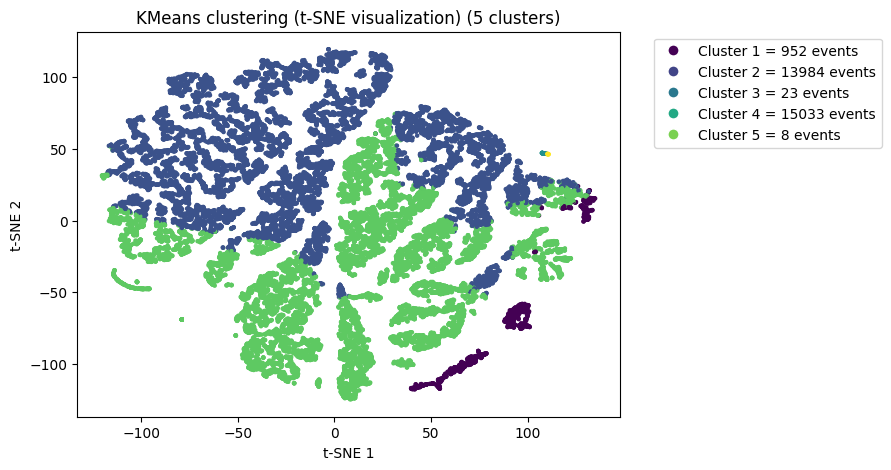

In [26]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt


# Optional subsampling of data
try:
    sample_size = int(input(f"Enter number of events to sample for t-SNE (max {len(df_features)}): "))
except ValueError:
    print(f"Invalid input. Using all events ({len(df_features)})")
    sample_size = len(df_features)

if sample_size < len(df_features):
    np.random.seed(42)
    sampled_indices = np.random.choice(len(df_features), size=sample_size, replace=False)
    df_features_sampled = df_features.iloc[sampled_indices].copy()
    print(f"Using {sample_size} randomly sampled events for t-SNE")
else:
    df_features_sampled = df_features.copy()
    print(f"Using all events ({len(df_features_sampled)}) for t-SNE")

# Feature matrix
feature_names = [col for col in df_features_sampled.columns if col not in ["Counter", "cluster"]]
X_p_sampled = df_features_sampled[feature_names].values
X_p_sampled = np.nan_to_num(X_p_sampled, nan=0.0, posinf=0.0, neginf=0.0)

# Scale features
from sklearn.preprocessing import StandardScaler
X_p_scaled_sampled = StandardScaler().fit_transform(X_p_sampled)


# K-Means clustering
try:
    n_clusters = int(input("Number of K-Means clusters: "))
except ValueError:
    print("Invalid input, defaulting to 3 clusters.")
    n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X_p_scaled_sampled)

# Fit clustering once on all events
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_p_scaled_sampled)

# Run t-SNE on the subsample
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_p_scaled_sampled)

# Plotting
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis", s=5)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"KMeans clustering (t-SNE visualization) ({n_clusters} clusters)")

# Legend showing cluster sizes
unique_labels, counts = np.unique(labels, return_counts=True)
cmap = plt.colormaps.get_cmap("viridis")  
colors = [cmap(i / len(unique_labels)) for i in range(len(unique_labels))]  # discrete colors

handles = [
    plt.Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor=colors[lab],   # use same colormap
        markersize=8
    )
    for lab in unique_labels
]
legend_labels = [f"Cluster {lab+1} = {cnt} events" for lab, cnt in zip(unique_labels, counts)]
plt.legend(handles, legend_labels, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


### Histogram for each feature

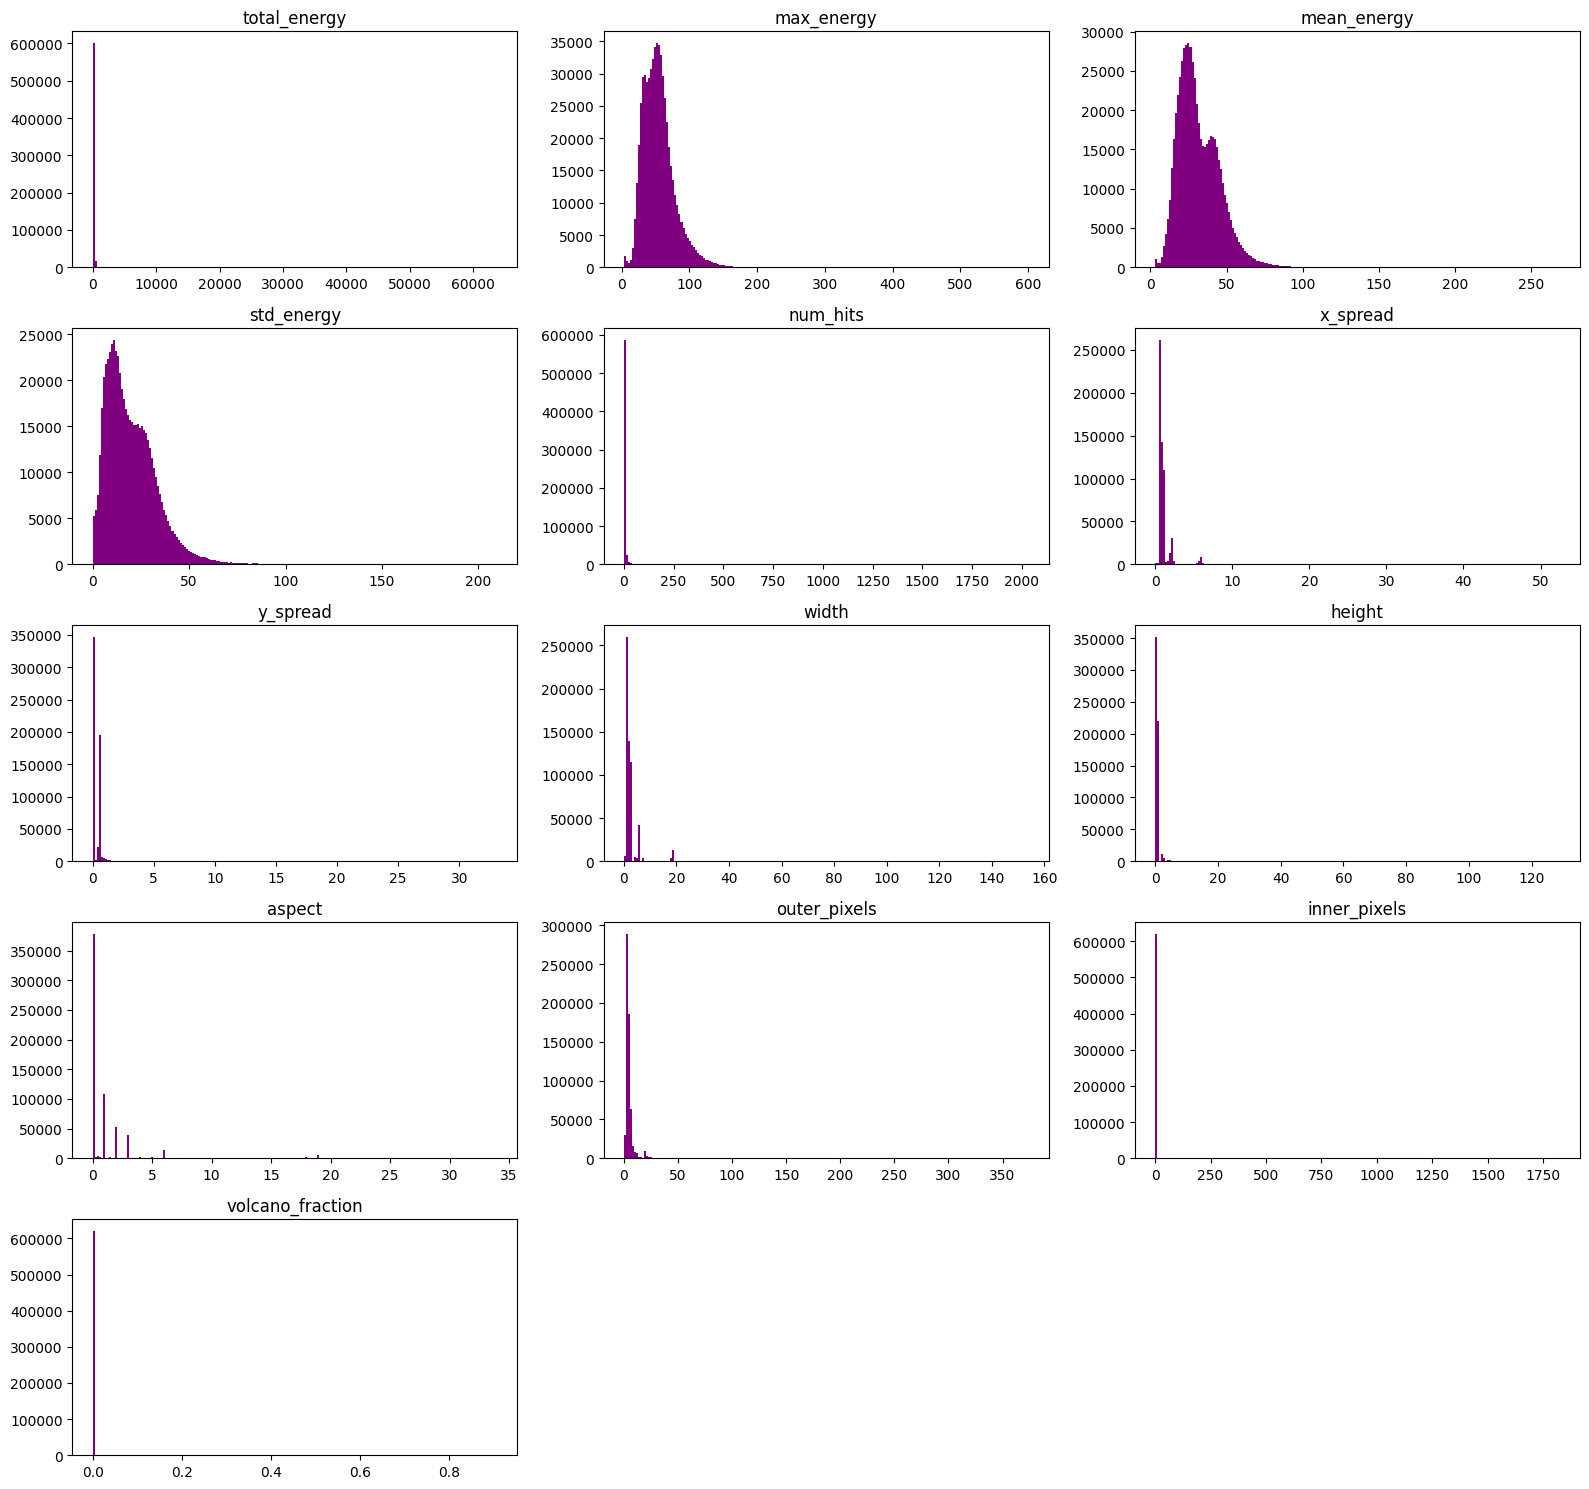

In [16]:
import math

feature_cols = [col for col in df_features.columns if col not in ["Counter", "cluster"]]

n_cols = 3  # number of histograms per row
n_rows = math.ceil(len(feature_cols) / n_cols)

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_features[col], bins=200, color="purple")
    plt.title(col)
    plt.tight_layout()

plt.show()
